In [1]:
import sys
from pathlib import Path

# notebooks/ → SERS-AI/ → src/ 를 sys.path에 추가
PROJECT_ROOT = Path.cwd().parent  # notebooks/../ = SERS-AI/
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"src dir:      {SRC_DIR}")
print(f"src exists:   {SRC_DIR.exists()}")
print(f".env exists:  {(PROJECT_ROOT / '.env').exists()}")
print(f"config.yaml:  {(PROJECT_ROOT / 'config.yaml').exists()}")

Project root: c:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI
src dir:      c:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\src
src exists:   True
.env exists:  True
config.yaml:  True


In [2]:
import os

# import 전에 환경변수 상태 확인
print("=== Before import (현재 환경변수) ===")
sers_vars_before = {k: v for k, v in os.environ.items() if 'SERS' in k or 'MLFLOW' in k}
if sers_vars_before:
    for k, v in sers_vars_before.items():
        print(f"  {k} = {v}")
else:
    print("  (없음 - .env에서 로딩될 예정)")

=== Before import (현재 환경변수) ===
  ALLUSERSPROFILE = C:\ProgramData
  MLFLOW_EXPERIMENT_NAME = sers-cancer-detection
  MLFLOW_TRACKING_URI = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\mlruns
  SERS_CLINICAL_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\clinical_data
  SERS_DATA_ROOT = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data
  SERS_ENV = development
  SERS_EQUIPMENT_TEST_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\equipment_test_data
  SERS_FIGURES_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\figures
  SERS_LOG_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\logs
  SERS_LOG_LEVEL = INFO
  SERS_MODEL_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\models
  SERS_PROCESSED_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\processed
  SERS_RAW_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화

In [3]:
from sers.config import(
    _PROJECT_ROOT,
    DATA_ROOT, RAW_DATA_DIR, CLINICAL_DATA_DIR, PROCESSED_DIR,
    RESULTS_DIR,FIG_DIR,MODEL_DIR,LOG_DIR,
    CONFIG_DIR,MLFLOW_TRACKING_URI,MLFLOW_EXPERIMENT_NAME,
    SERS_ENV,LOG_LEVEL,
    load_config, cfg,
    PreprocessingConfig, QCConfig, ModelingConfig, Config
)

In [4]:
# import 후 환경변수 확인 (.env에서 로딩됐는지)
print("=== After import (환경변수 로딩 결과) ===")
sers_vars_after = {k: v for k, v in os.environ.items() if 'SERS' in k or 'MLFLOW' in k or 'CONFIG' in k}
for k, v in sorted(sers_vars_after.items()):
    status = "🆕 .env" if k not in sers_vars_before else "♻️  기존"
    print(f"  {status}  {k} = {v}")

=== After import (환경변수 로딩 결과) ===
  ♻️  기존  ALLUSERSPROFILE = C:\ProgramData
  🆕 .env  APPLICATIONINSIGHTS_CONFIGURATION_CONTENT = {}
  🆕 .env  CONFIG_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\
  ♻️  기존  MLFLOW_EXPERIMENT_NAME = sers-cancer-detection
  ♻️  기존  MLFLOW_TRACKING_URI = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\mlruns
  ♻️  기존  SERS_CLINICAL_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\clinical_data
  ♻️  기존  SERS_DATA_ROOT = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data
  ♻️  기존  SERS_ENV = development
  ♻️  기존  SERS_EQUIPMENT_TEST_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\equipment_test_data
  ♻️  기존  SERS_FIGURES_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\figures
  ♻️  기존  SERS_LOG_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\logs
  ♻️  기존  SERS_LOG_LEVEL = INFO
  ♻️  기존  SERS_MODEL_DIR = C:\Users

In [5]:
print("=== Path Constants ===")
paths = {
    "_PROJECT_ROOT":    _PROJECT_ROOT,
    "DATA_ROOT":        DATA_ROOT,
    "RAW_DATA_DIR":     RAW_DATA_DIR,
    "CLINICAL_DATA_DIR": CLINICAL_DATA_DIR,
    "PROCESSED_DIR":    PROCESSED_DIR,
    "RESULTS_DIR":      RESULTS_DIR,
    "FIG_DIR":          FIG_DIR,
    "MODEL_DIR":        MODEL_DIR,
    "LOG_DIR":          LOG_DIR,
    "CONFIG_DIR":       CONFIG_DIR,
}

max_name = max(len(n) for n in paths)
for name, path in paths.items():
    exists = "✅" if path.exists() else "❌"
    print(f"  {exists} {name:<{max_name}} = {path}")

print(f"\n  MLFLOW_TRACKING_URI   = {MLFLOW_TRACKING_URI}")
print(f"  MLFLOW_EXPERIMENT_NAME = {MLFLOW_EXPERIMENT_NAME}")
print(f"  SERS_ENV              = {SERS_ENV}")
print(f"  LOG_LEVEL             = {LOG_LEVEL}")

=== Path Constants ===
  ✅ _PROJECT_ROOT     = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI
  ✅ DATA_ROOT         = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data
  ✅ RAW_DATA_DIR      = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\raw_data
  ✅ CLINICAL_DATA_DIR = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\clinical_data
  ✅ PROCESSED_DIR     = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\processed
  ✅ RESULTS_DIR       = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\results
  ✅ FIG_DIR           = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\figures
  ✅ MODEL_DIR         = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\models
  ✅ LOG_DIR           = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\logs
  ✅ CONFIG_DIR        = C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI

  MLFLOW_TRACKING_URI   = C:\Users\YoonInsu_H

In [6]:
# 경로 내부 파일 존재 확인
print("=== RAW_DATA_DIR 내부 ===")
if RAW_DATA_DIR.exists():
    subdirs = sorted([d.name for d in RAW_DATA_DIR.iterdir() if d.is_dir()])
    print(f"  폴더 {len(subdirs)}개: {subdirs}")
else:
    print(f"  ❌ 경로가 존재하지 않음: {RAW_DATA_DIR}")

print("\n=== CLINICAL_DATA_DIR 내부 ===")
if CLINICAL_DATA_DIR.exists():
    files = sorted([f.name for f in CLINICAL_DATA_DIR.iterdir()])[:10]
    print(f"  파일 목록 (최대 10개): {files}")
else:
    print(f"  ❌ 경로가 존재하지 않음: {CLINICAL_DATA_DIR}")

=== RAW_DATA_DIR 내부 ===
  폴더 12개: ['1. Prostate cancer (100개)', '10-1. C-Pancreatic cancer (70개)', '10-2. S-Pancreatic cancer (72개)', '10-3. Y-Pancreatic cancer (27개)', '2. Breast cancer (30개)', '3. Ovarian cancer (70개)', '4. Lung cancer (300개)', '5. Normal (100개)', '6. Diabetes (100개)', '7. High blood pressure (100개)', '8. High blood pressure + Diabetes (100개)', '9. Colorectal cancer (300개)']

=== CLINICAL_DATA_DIR 내부 ===
  파일 목록 (최대 10개): ['1. S-Pancreatic cancer 임상정보', '2. Lung cancer 임상정보.xlsx', '3. Colorectal cancer 임상정보.xlsx', '4. High blood pressure 임상정보.xlsx', '5. Diabetes 임상정보.xlsx', 'CRC_patients.xlsx', 'DIA_patients.xlsx', 'HBP_patients.xlsx', 'H_D_patients.xlsx', 'Lung_patients.xlsx']


In [7]:
# 방법 1: 자동 로딩된 cfg 확인
print("=== Auto-loaded cfg (import 시 자동 로딩) ===")
if cfg is not None:
    print(f"  ✅ cfg 로딩됨")
    print(f"  Type: {type(cfg).__name__}")
else:
    print(f"  ❌ cfg is None (config.yaml을 찾지 못함)")
    print(f"  Expected at: {CONFIG_DIR / 'config.yaml'}")

=== Auto-loaded cfg (import 시 자동 로딩) ===
  ✅ cfg 로딩됨
  Type: Config


In [8]:
config = load_config()
# Config 내용 출력
print("=== folder_to_group ===")
for folder, group in config.folder_to_group.items():
    print(f"  {folder:30s} → {group}")

print(f"\n=== Preprocessing ===")
print(f"  do_smooth:       {config.preprocessing.do_smooth}")
print(f"  smooth_window:   {config.preprocessing.smooth_window}")
print(f"  smooth_poly:     {config.preprocessing.smooth_poly}")
print(f"  baseline_window: {config.preprocessing.baseline_window}")
print(f"  use_snv:         {config.preprocessing.use_snv}")

print(f"\n=== QC ===")
print(f"  corr_threshold:  {config.qc.corr_threshold}")
print(f"  rsd_threshold:   {config.qc.rsd_threshold}")
print(f" intensity_gate_ratio:    {config.qc.intensity_gate_ratio}")

print(f"  expected_reps:   {config.qc.expected_reps}")

print(f"\n=== Modeling ===")
print(f"  n_splits:        {config.modeling.n_splits}")
print(f"  use_pca:         {config.modeling.use_pca}")
print(f"  pca_components:  {config.modeling.pca_components}")
print(f"  random_state:    {config.modeling.random_state}")

=== folder_to_group ===
  2. Diabetes (100개)             → DIA
  3. High blood pressure (100개)  → HBP
  4. High blood pressure + Diabetes (100개) → H.D.
  5. Lung cancer (30개)           → LUN
  6. Ovarian cancer (70개)        → OVA
  7. Prostate cancer (100개)      → PRO
  8. S-Pancreatic cancer (41개)   → S-PAN
  Breast cancer (30개)            → BRE
  Normal (100개)                  → NOR

=== Preprocessing ===
  do_smooth:       True
  smooth_window:   11
  smooth_poly:     3
  baseline_window: 101
  use_snv:         True

=== QC ===
  corr_threshold:  0.95
  rsd_threshold:   5.0
 intensity_gate_ratio:    0.1
  expected_reps:   5

=== Modeling ===
  n_splits:        5
  use_pca:         False
  pca_components:  30
  random_state:    42


In [9]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sers.io import (
    DatasetResult, SpectrumID, read_spectrum, parse_filename,
    find_spectra, load_dataset, make_common_grid
)
from sers.config import SERS_EQUIPMENT_TEST_DATA_DIR

# --- Handheld-specific readers ---
def read_handheld_spectrum(path: Path):
    """Read handheld key-value CSV with Intensities field."""
    meta = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip().strip('"')
            parts = line.split('","')
            if len(parts) == 2:
                meta[parts[0]] = parts[1].rstrip('"')
    first_wn = float(meta["Firstwavenumber"])
    last_wn = float(meta["LastWavenumber"])
    intensities = np.array([float(v) for v in meta["Intensities"].split(",")])
    wavenumbers = np.linspace(first_wn, last_wn, len(intensities))
    return wavenumbers, intensities

def parse_handheld_filename(path: Path, fallback_group: str = "UNK") -> SpectrumID:
    """Parse NOR 100_10(1)_Sample_... format. Skip _ave files."""
    stem = path.stem
    if "_ave" in stem:
        raise ValueError(f"Skipping average file: {path.name}")
    m = re.match(r"^([A-Za-z]+(?:\.[A-Za-z]+)*\.?)[\s_]?(\d+)_(\d+)\(\d+\)_", stem)
    if m:
        group, sid, rep = m.groups()
        return SpectrumID(group.strip().upper(), sid, int(rep))
    raise ValueError(f"Cannot parse: {path.name}")

def _load_equipment_manual(directory: Path, reader, parser, pattern, fallback_group="NOR"):        
    """Generic loader for equipment folders without load_dataset."""
    spectra, metadata, failed = {}, [], []
    files = sorted(directory.rglob(pattern))
    for f in tqdm(files, desc=directory.parent.name + "/" + directory.name):
        if "_ave" in f.stem:
            continue
        try:
            spec_id = parser(f, fallback_group=fallback_group)
            x, y = reader(f)
            key = (spec_id.group, spec_id.sample_id, spec_id.replicate)
            spectra[key] = (x, y)
            metadata.append({
                "file": f.name, "folder": f.parent.name,
                "group": spec_id.group, "sample_id": spec_id.sample_id,
                "replicate": spec_id.replicate, "n_points": len(x),
                "x_min": x.min(), "x_max": x.max(),
                "y_min": y.min(), "y_max": y.max(),
            })
        except Exception as e:
            failed.append(f)
    return DatasetResult(spectra=spectra, metadata=pd.DataFrame(metadata), failed_files=failed)    

print("Equipment loaders defined.")

Equipment loaders defined.


In [10]:
from sers.config import SERS_EQUIPMENT_TEST_DATA_DIR    

from sers.io import load_dataset
# ============================================================
# Load all 4 equipment types
# ============================================================
EQ_DIR = SERS_EQUIPMENT_TEST_DATA_DIR
equipment_results = {}

# 1. Handheld (custom format, subfolder structure)
equipment_results["handheld"] = _load_equipment_manual(
    EQ_DIR / "handheld" / "1. NOR",
    reader=read_handheld_spectrum,
    parser=parse_handheld_filename,
    pattern="*.csv",
    fallback_group="NOR",
)

# 2. Medical (standard 2-col .txt, subfolder structure)
equipment_results["medical_removed"] = load_dataset(
    EQ_DIR / "medical_removed",
    folder_to_group=config.equipment_folder_to_group["medical_removed"].sample_folder_to_group,
    pattern="*.txt",
)
equipment_results['medical_raw'] = load_dataset(
    EQ_DIR / "medical_raw",
    folder_to_group=config.equipment_folder_to_group["medical_raw"].sample_folder_to_group,
    pattern="*.txt",
)
# 3. Nanoscope (standard 2-col .txt, subfolder structure)
equipment_results["nanoscope"] = load_dataset(
    EQ_DIR / "nanoscope"/"1. NOR",
    folder_to_group=config.equipment_folder_to_group["nanoscope"].sample_folder_to_group,
    pattern="*.txt",
)

# 4. Thermo (standard CSV, files directly in folder — no subfolder)
equipment_results["thermo"] = _load_equipment_manual(
    EQ_DIR / "thermo"/"1. NOR",
    reader=read_spectrum,
    parser=parse_filename,
    pattern="*.CSV",
    fallback_group="NOR",
)

# Summary
print("\n=== Equipment Loading Summary ===")
for eq_name, res in equipment_results.items():
    print(f"  {eq_name:12s}: {len(res):5d} spectra, "
        f"{len(res.failed_files):3d} failed, groups={res.groups()}")


thermo/1. NOR: 100%|██████████| 2100/2100 [00:12<00:00, 162.84it/s]


=== Equipment Loading Summary ===
  handheld    :  2000 spectra,   0 failed, groups=['NOR']
  medical_removed:  2000 spectra, 100 failed, groups=['NOR']
  medical_raw :  2000 spectra, 101 failed, groups=['NOR']
  nanoscope   :  2000 spectra,  97 failed, groups=['NOR']
  thermo      :  2000 spectra,   0 failed, groups=['NOR']


### RAW QC Analysis


  QC: handheld (2000 spectra)
  Grid: 400.0 ~ 2300.0 cm-1, 1901 pts

  QC: medical_removed (2000 spectra)
  Grid: 100.0 ~ 3200.0 cm-1, 2001 pts

  QC: medical_raw (2000 spectra)
  Grid: 100.0 ~ 3200.0 cm-1, 2001 pts

  QC: nanoscope (2000 spectra)
  Grid: 100.0 ~ 3200.0 cm-1, 2001 pts

  QC: thermo (2000 spectra)
  Grid: 50.6 ~ 3300.0 cm-1, 1686 pts

  CROSS-EQUIPMENT SUMMARY

  HANDHELD
    Samples: 100, Failures: 8 (8.0%)
    Gate failures: 0/2000 spectra
    RSD:  2.71% ± 1.26%
    Corr: 0.9987 ± 0.0007

  MEDICAL_REMOVED
    Samples: 100, Failures: 98 (98.0%)
    Gate failures: 0/2000 spectra
    RSD:  7.70% ± 4.32%
    Corr: 0.7826 ± 0.1954

  MEDICAL_RAW
    Samples: 100, Failures: 96 (96.0%)
    Gate failures: 24/2000 spectra
    RSD:  11.43% ± 9.64%
    Corr: 0.9924 ± 0.0162

  NANOSCOPE
    Samples: 100, Failures: 9 (9.0%)
    Gate failures: 14/2000 spectra
    RSD:  2.13% ± 0.53%
    Corr: 0.9715 ± 0.0138

  THERMO
    Samples: 100, Failures: 0 (0.0%)
    Gate failures: 0/20

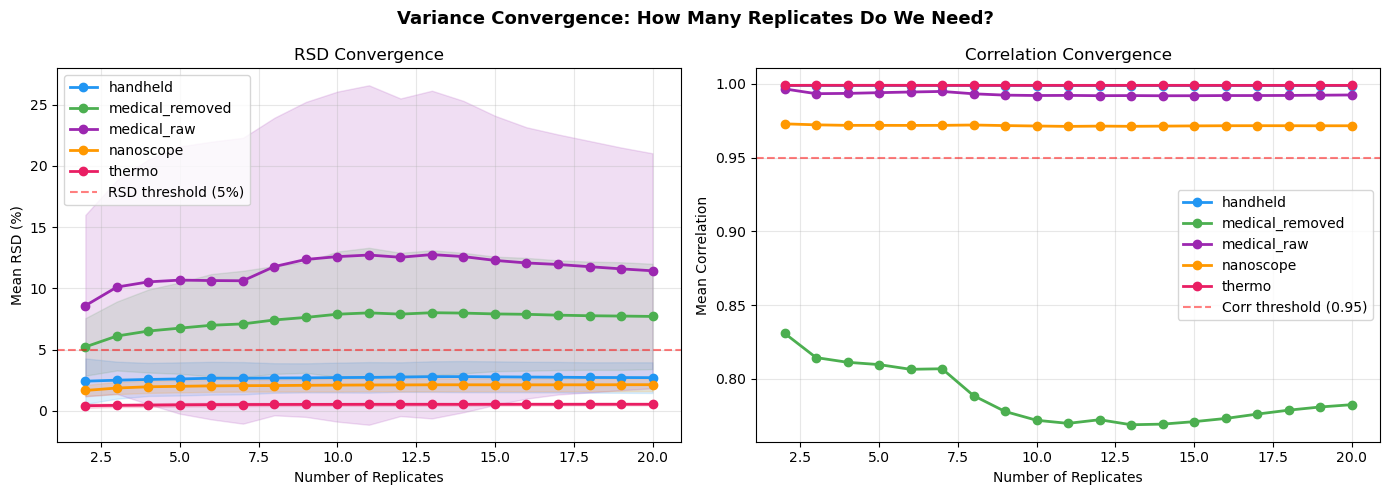

In [11]:
# ============================================================
# QC Analysis per Equipment (v0.5.0)
# ============================================================
from sers.qc import run_qc_pipeline, calculate_variance_convergence
from sers.config import load_config, RESULTS_DIR, QCConfig
from sers.io import make_common_grid

config = load_config()

all_qc = {}
eq_grids = {}

for eq_name, res in equipment_results.items():
    if len(res) == 0:
        print(f"\n--- {eq_name}: no spectra, skipping ---")
        continue

    print(f"\n{'='*60}")
    print(f"  QC: {eq_name} ({len(res)} spectra)")
    print(f"{'='*60}")

    x_arrays = [x for x, y in res.spectra.values()]
    eq_grids[eq_name] = make_common_grid(x_arrays)
    grid = eq_grids[eq_name]
    print(f"  Grid: {grid.min():.1f} ~ {grid.max():.1f} cm-1, {len(grid)} pts")

    # v0.5: 4 return values
    gate_df, qc_stats, failures, group_summary = run_qc_pipeline(
        res.spectra,
        grid,
        qc_config=config.qc,
        save_report=str(RESULTS_DIR / f"qc_report_{eq_name}.txt"),
        save_json=str(RESULTS_DIR / f"qc_report_{eq_name}.json"),
    )

    all_qc[eq_name] = {
        "grid": grid,
        "gate_df": gate_df,
        "qc_stats": qc_stats,
        "failures": failures,
        "group_summary": group_summary,
    }

# ============================================================
# Summary
# ============================================================
print("\n" + "="*70)
print("  CROSS-EQUIPMENT SUMMARY")
print("="*70)

for eq_name, qc in all_qc.items():
    stats = qc["qc_stats"]
    fails = qc["failures"]
    gate = qc["gate_df"]
    n_gate_fail = (~gate["gate_pass"]).sum() if len(gate) > 0 else 0

    print(f"\n  {eq_name.upper()}")
    print(f"    Samples: {len(stats)}, Failures: {len(fails)} ({100*len(fails)/len(stats):.1f}%)")
    print(f"    Gate failures: {n_gate_fail}/{len(gate)} spectra")
    print(f"    RSD:  {stats['mean_rsd'].mean():.2f}% ± {stats['mean_rsd'].std():.2f}%")
    print(f"    Corr: {stats['mean_corr'].mean():.4f} ± {stats['mean_corr'].std():.4f}")

# ============================================================
# Variance Convergence (Optimal Replicate Count)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Variance Convergence: How Many Replicates Do We Need?", fontsize=13, fontweight="bold")

# colors = {"handheld": "#2196F3", "medical": "#4CAF50", "nanoscope": "#FF9800", "thermo": "#E91E63"}
# colors = {"medical_removed": "#4CAF50", "medical_raw": "#2196F3"}
colors = {"handheld": "#2196F3", "medical_removed": "#4CAF50", "medical_raw": "#9C27B0", "nanoscope": "#FF9800", "thermo": "#E91E63"}
for eq_name, res in equipment_results.items():
    if len(res) == 0:
        continue

    grid = eq_grids[eq_name]
    conv_df = calculate_variance_convergence(res.spectra, grid)

    if len(conv_df) == 0:
        continue

    c = colors.get(eq_name, "gray")

    # RSD convergence
    axes[0].plot(conv_df["n_reps"], conv_df["mean_rsd"], "o-", color=c, label=eq_name, linewidth=2)
    axes[0].fill_between(
        conv_df["n_reps"],
        conv_df["mean_rsd"] - conv_df["std_rsd"],
        conv_df["mean_rsd"] + conv_df["std_rsd"],
        alpha=0.15, color=c
    )

    # Correlation convergence
    axes[1].plot(conv_df["n_reps"], conv_df["mean_corr"], "o-", color=c, label=eq_name, linewidth=2)

    # Print table
    print(f"\n  {eq_name.upper()} — Variance Convergence:")
    print(f"  {'n_reps':>6}  {'mean_rsd':>10}  {'std_rsd':>10}  {'mean_corr':>10}  {'n_samples':>10}")
    for _, row in conv_df.iterrows():
        print(f"  {int(row['n_reps']):>6}  {row['mean_rsd']:>10.3f}  {row['std_rsd']:>10.3f}  {row['mean_corr']:>10.5f}  {int(row['n_samples']):>10}")

axes[0].axhline(y=5.0, color="red", ls="--", alpha=0.5, label="RSD threshold (5%)")
axes[0].set_xlabel("Number of Replicates")
axes[0].set_ylabel("Mean RSD (%)")
axes[0].set_title("RSD Convergence")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(y=0.95, color="red", ls="--", alpha=0.5, label="Corr threshold (0.95)")
axes[1].set_xlabel("Number of Replicates")
axes[1].set_ylabel("Mean Correlation")
axes[1].set_title("Correlation Convergence")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "variance_convergence.png"), dpi=150, bbox_inches="tight")
plt.show()

### 각 장비별 성능 비교표

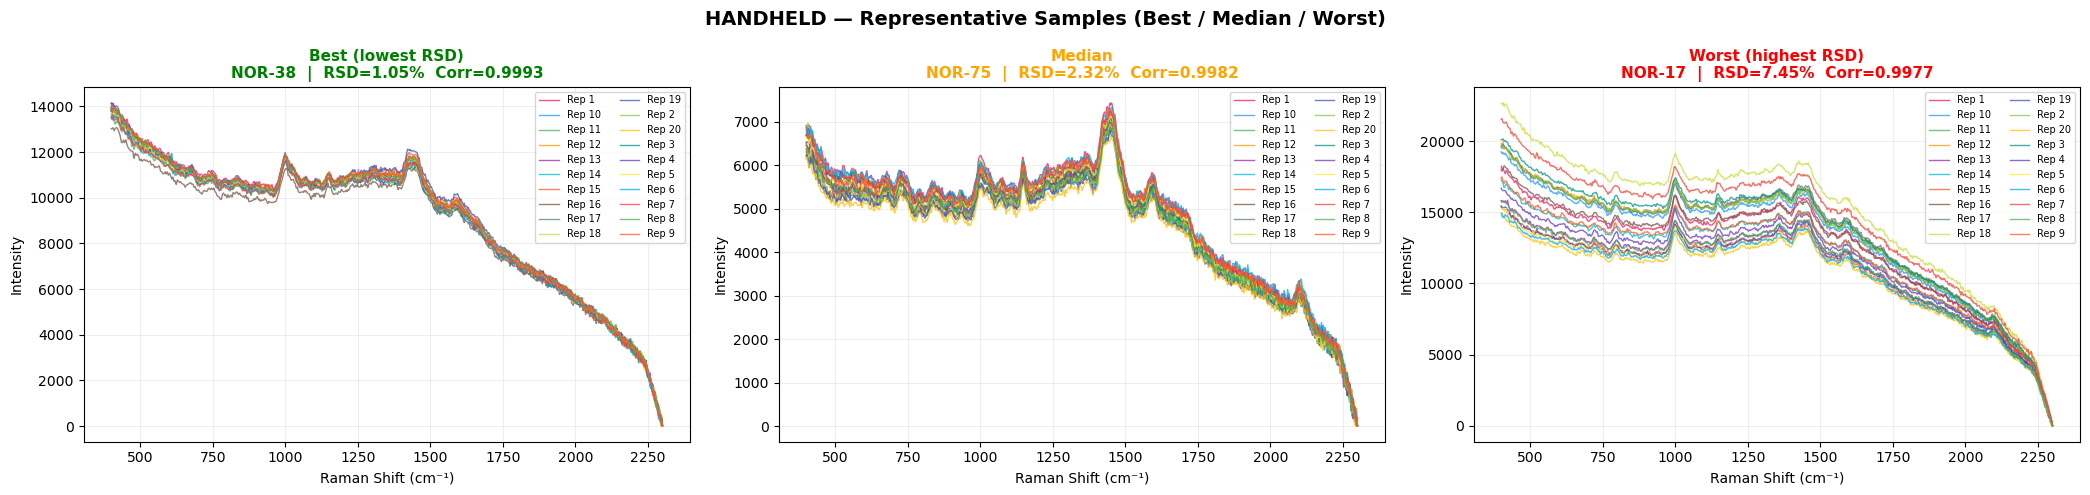

  handheld: saved handheld_replicate_best_median_worst.png


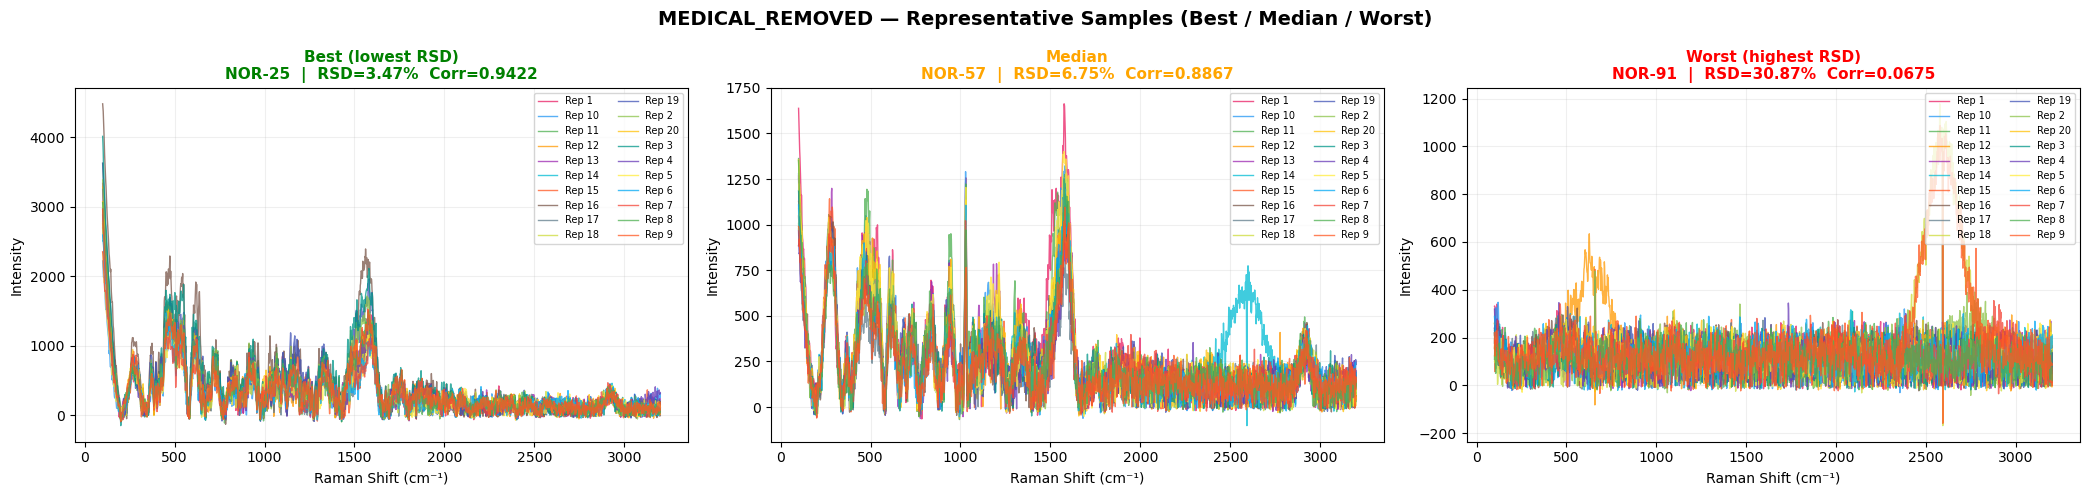

  medical_removed: saved medical_removed_replicate_best_median_worst.png


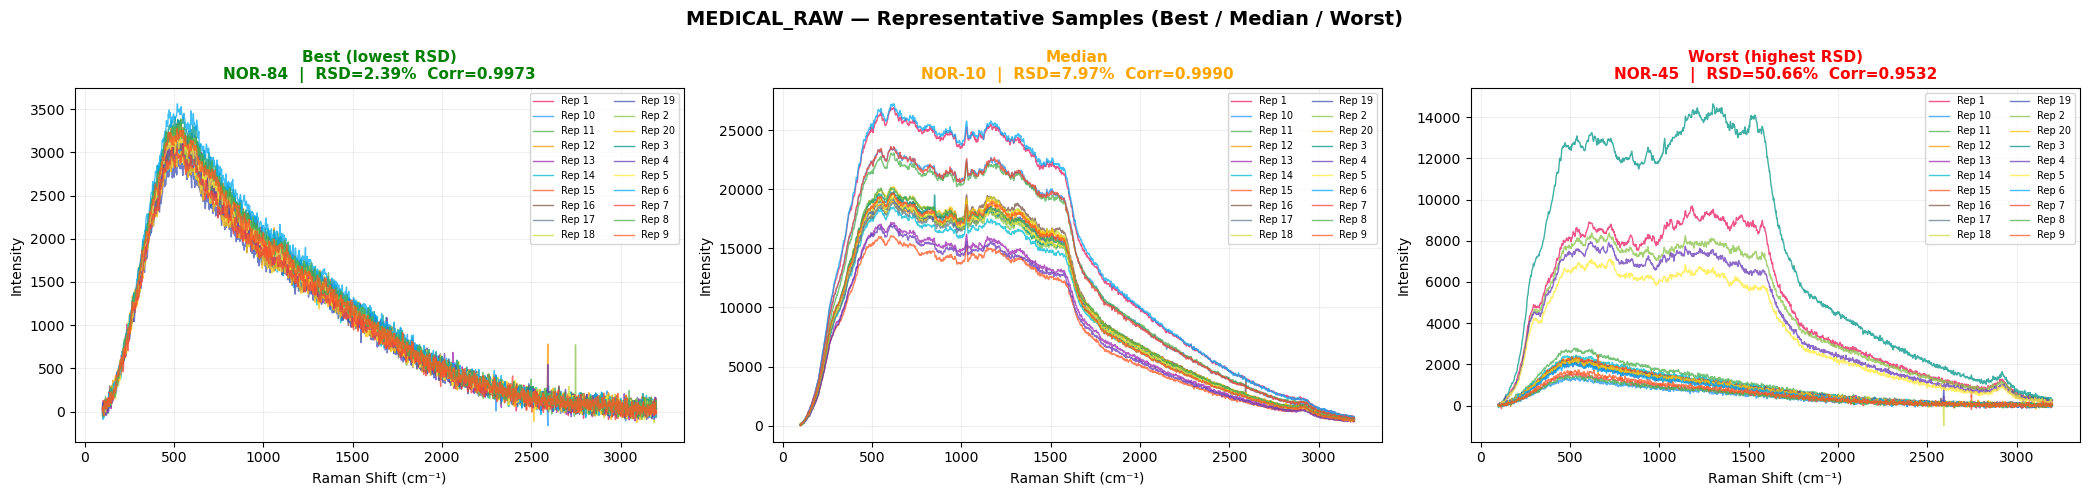

  medical_raw: saved medical_raw_replicate_best_median_worst.png


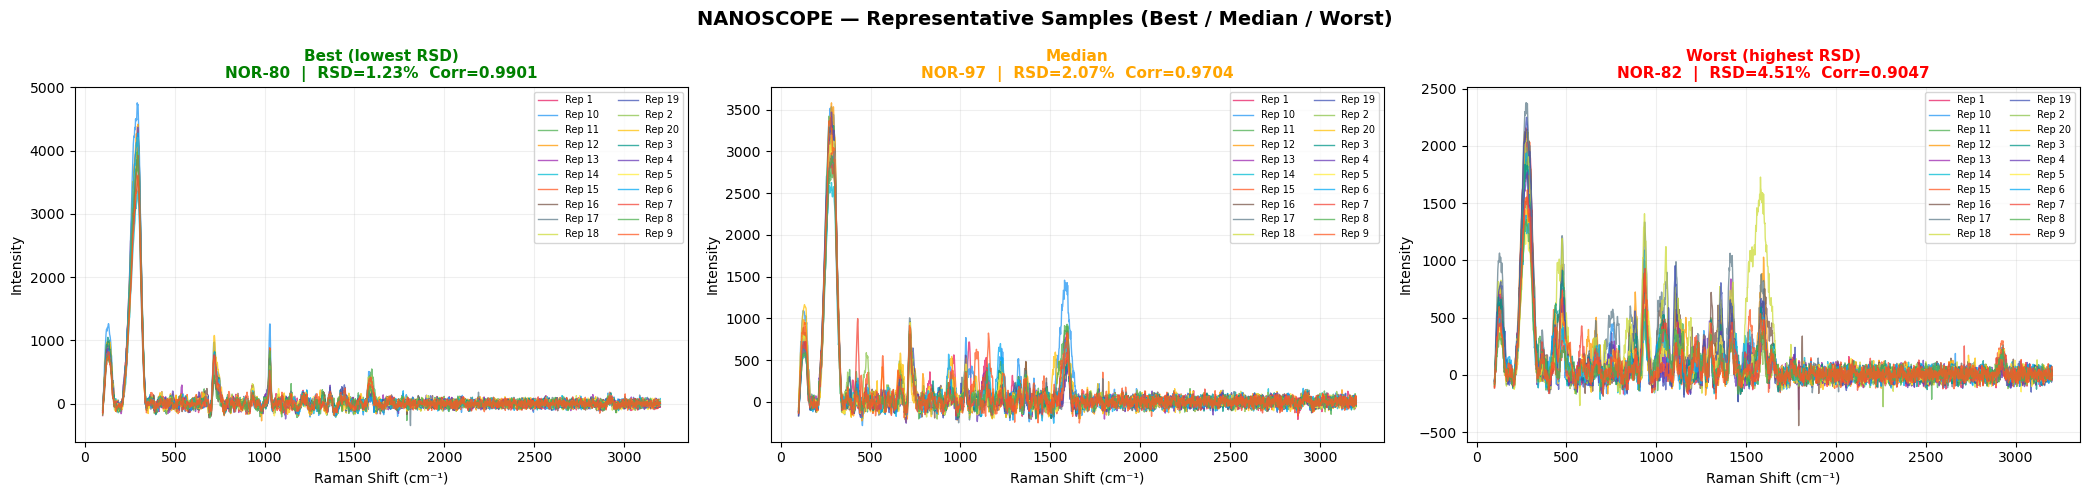

  nanoscope: saved nanoscope_replicate_best_median_worst.png


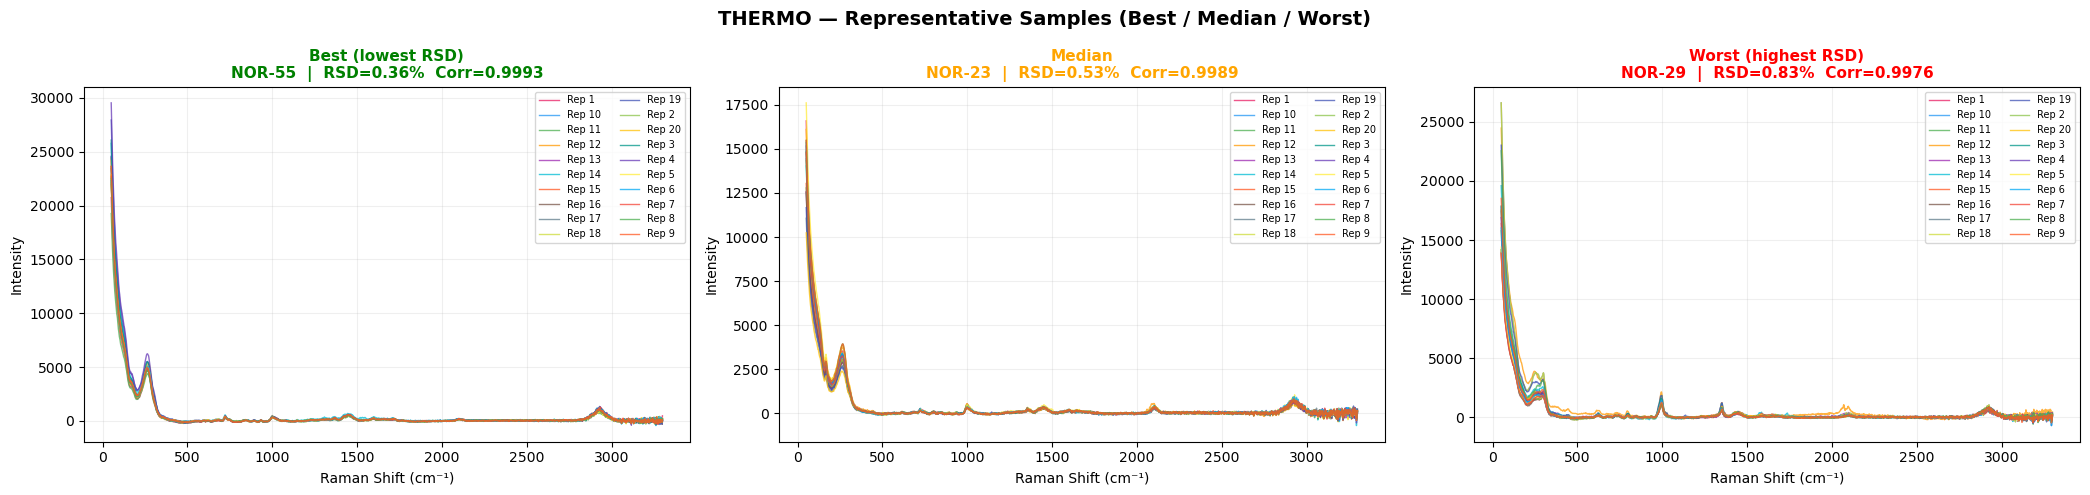

  thermo: saved thermo_replicate_best_median_worst.png

Figures saved to: C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\results\replicate_figures


In [12]:
# ============================================================
# Combined Replicate Figure per Equipment
# 3 representative samples: Worst / Median / Best by RSD
# ============================================================                                                      import numpy as np
import pandas as pd                                                                                          
import matplotlib.pyplot as plt
from sers.qc import interpolate_to_grid
from sers.config import RESULTS_DIR

# Replicate colors
rep_colors = [
    "#E91E63", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0",
    "#00BCD4", "#FF5722", "#795548", "#607D8B", "#CDDC39",
    "#3F51B5", "#8BC34A", "#FFC107", "#009688", "#673AB7",
    "#FFEB3B", "#03A9F4", "#F44336", "#4CAF50", "#FF5722",
]

fig_dir = RESULTS_DIR / "replicate_figures"
fig_dir.mkdir(parents=True, exist_ok=True)

for eq_name, res in equipment_results.items():
    if len(res) == 0:
        continue

    spectra = res.spectra
    grid = eq_grids[eq_name]
    stats = all_qc[eq_name]["qc_stats"]

    # Group replicates by sample
    samples = {}
    for (group, sid, rep), (x, y) in spectra.items():
        key = (group, sid)
        if key not in samples:
            samples[key] = []
        y_interp = interpolate_to_grid(x, y, grid)
        samples[key].append((rep, y_interp))

    # Sort by RSD ascending → pick worst, median, best
    stats_sorted = stats.sort_values("mean_rsd", ascending=True)
    n = len(stats_sorted)
    pick_idx = {
        "Best (lowest RSD)":   0,
        "Median":              n // 2,
        "Worst (highest RSD)": n - 1,
    }
    titles_colors = {
        "Best (lowest RSD)":   "green",
        "Median":              "orange",
        "Worst (highest RSD)": "red",
    }

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle(f"{eq_name.upper()} — Representative Samples (Best / Median / Worst)",
                fontsize=14, fontweight="bold")

    for ax, (label, idx) in zip(axes, pick_idx.items()):
        row = stats_sorted.iloc[idx]
        sample_key = (row["group"], row["sample_id"])
        reps = samples.get(sample_key, [])

        for i, (rep, y) in enumerate(reps):
            ax.plot(grid, y, color=rep_colors[i % len(rep_colors)],
                    alpha=0.75, linewidth=1.0, label=f"Rep {rep}")

        ax.set_title(
            f"{label}\n{sample_key[0]}-{sample_key[1]}  |  "
            f"RSD={row['mean_rsd']:.2f}%  Corr={row['mean_corr']:.4f}",
            fontsize=11, fontweight="bold", color=titles_colors[label],
        )
        ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=10)
        ax.set_ylabel("Intensity", fontsize=10)
        ax.legend(fontsize=7, loc="upper right", ncol=2)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    fname = f"{eq_name}_replicate_best_median_worst.png"
    fig.savefig(fig_dir / fname, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  {eq_name}: saved {fname}")

print(f"\nFigures saved to: {fig_dir}")


In [13]:
from sers.config import RAW_DATA_DIR
from pathlib import Path

raw_dir = Path(RAW_DATA_DIR)
print(f"RAW_DATA_DIR: {raw_dir}")
print(f"Exists: {raw_dir.exists()}")

if raw_dir.exists():
    print(f"\nSubfolders:")
    for p in sorted(raw_dir.iterdir()):
        if p.is_dir():
            files = list(p.glob("**/*.*"))
            print(f"  {p.name}/  ({len(files)} files)")
            for f in list(p.glob("*.*"))[:3]:
                print(f"    {f.name}")
        elif p.is_file():
            print(f"  [file] {p.name}")

RAW_DATA_DIR: C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\raw_data
Exists: True

Subfolders:
  1. Prostate cancer (100개)/  (600 files)
    PRO 100_1.CSV
    PRO 100_2.CSV
    PRO 100_3.CSV
  10-1. C-Pancreatic cancer (70개)/  (420 files)
    CPAN 10_1.CSV
    CPAN 10_2.CSV
    CPAN 10_3.CSV
  10-2. S-Pancreatic cancer (72개)/  (432 files)
    SPAN 10_1.CSV
    SPAN 10_2.CSV
    SPAN 10_3.CSV
  10-3. Y-Pancreatic cancer (27개)/  (234 files)
    Po. YPAN 26_1.CSV
    Po. YPAN 26_2.CSV
    Po. YPAN 26_3.CSV
  2. Breast cancer (30개)/  (180 files)
    BRE 10_1.CSV
    BRE 10_2.CSV
    BRE 10_3.CSV
  3. Ovarian cancer (70개)/  (420 files)
    OVA 10_1.CSV
    OVA 10_2.CSV
    OVA 10_3.CSV
  4. Lung cancer (300개)/  (1800 files)
    LUN 100_1.CSV
    LUN 100_2.CSV
    LUN 100_3.CSV
  5. Normal (100개)/  (600 files)
    NOR 100_1.CSV
    NOR 100_2.CSV
    NOR 100_3.CSV
  6. Diabetes (100개)/  (600 files)
    DIA 100_1.CSV
    DIA 100_2.CSV
    DIA 100_3.CSV
  7. High blood press

2026-02-25 14:57:52,965 - INFO - ============================================================
2026-02-25 14:57:52,967 - INFO - Base Model QC Pipeline — Group Comparison
2026-02-25 14:57:52,967 - INFO - ============================================================
2026-02-25 14:57:52,981 - WARNING - Could not load group_metadata: [Errno 2] No such file or directory: 'config.yaml'
2026-02-25 14:57:52,982 - INFO - 
[1/7] Loading spectra...
2026-02-25 14:57:52,983 - INFO - Data directory: C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\data\raw_data
2026-02-25 14:57:52,984 - INFO - Groups to load: 12
2026-02-25 14:57:52,994 - INFO -   PRO: 600 files in '1. Prostate cancer (100개)'
2026-02-25 14:57:52,995 - WARNING -     Failed: PRO 100_ave.CSV — Cannot parse filename: PRO 100_ave.CSV
2026-02-25 14:57:52,996 - WARNING -     Failed: PRO 10_ave.CSV — Cannot parse filename: PRO 10_ave.CSV
2026-02-25 14:57:52,997 - WARNING -     Failed: PRO 11_ave.CSV — Cannot parse filename: PRO 11_


  CROSS-GROUP QC SUMMARY

  NOR (control)
    Samples: 100, Failures: 0 (0.0%)
    RSD:  0.50% ± 0.17%
    Corr: 0.9991 ± 0.0008

  DIA (non_cancer)
    Samples: 100, Failures: 0 (0.0%)
    RSD:  0.47% ± 0.14%
    Corr: 0.9992 ± 0.0004

  HBP (non_cancer)
    Samples: 100, Failures: 0 (0.0%)
    RSD:  0.55% ± 0.18%
    Corr: 0.9986 ± 0.0023

  H.D. (non_cancer)
    Samples: 100, Failures: 0 (0.0%)
    RSD:  0.48% ± 0.14%
    Corr: 0.9992 ± 0.0006

  PRO (cancer)
    Samples: 100, Failures: 0 (0.0%)
    RSD:  0.41% ± 0.13%
    Corr: 0.9995 ± 0.0004

  BRE (cancer)
    Samples: 30, Failures: 0 (0.0%)
    RSD:  0.41% ± 0.12%
    Corr: 0.9993 ± 0.0005

  OVA (cancer)
    Samples: 70, Failures: 0 (0.0%)
    RSD:  0.52% ± 0.16%
    Corr: 0.9991 ± 0.0008

  LUN (cancer)
    Samples: 300, Failures: 0 (0.0%)
    RSD:  0.55% ± 0.18%
    Corr: 0.9989 ± 0.0009

  CRC (cancer)
    Samples: 300, Failures: 0 (0.0%)
    RSD:  0.59% ± 0.20%
    Corr: 0.9989 ± 0.0010

  CPAN (cancer)
    Samples: 70, F

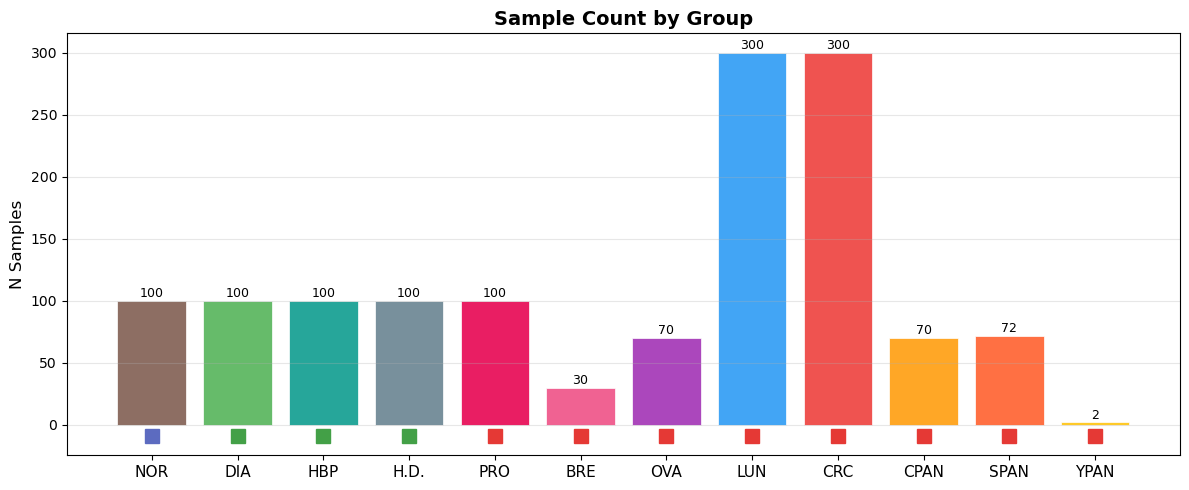

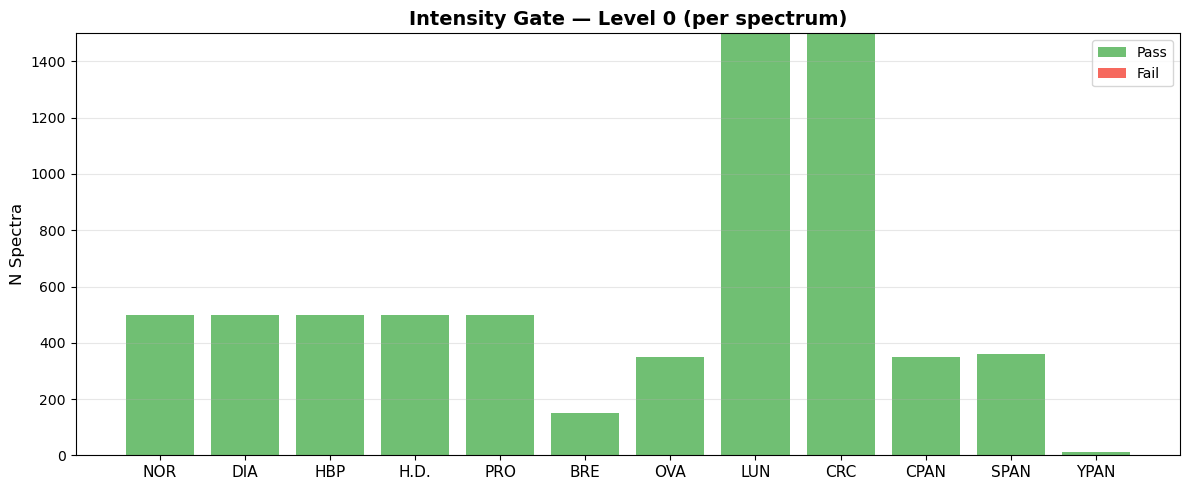

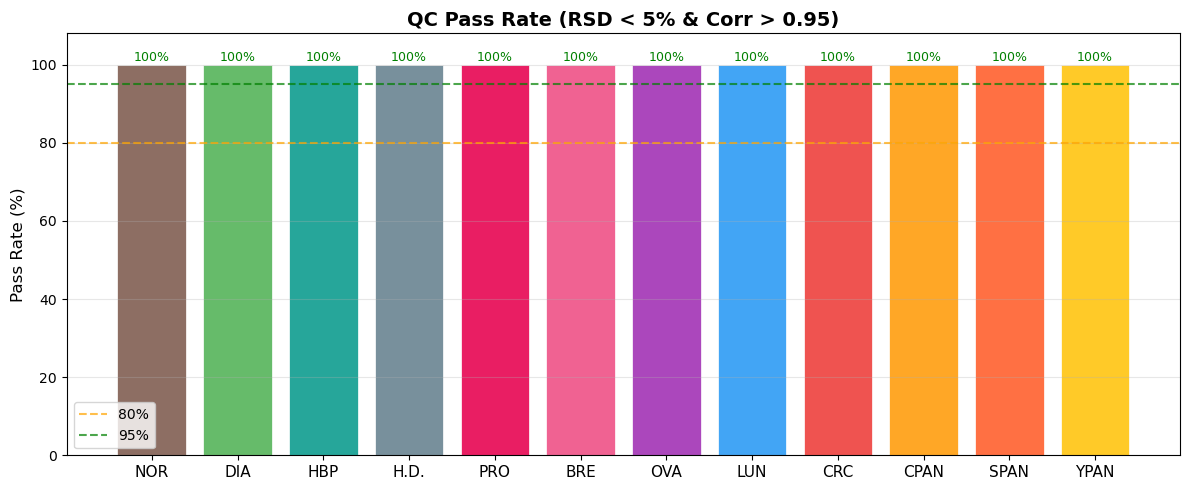

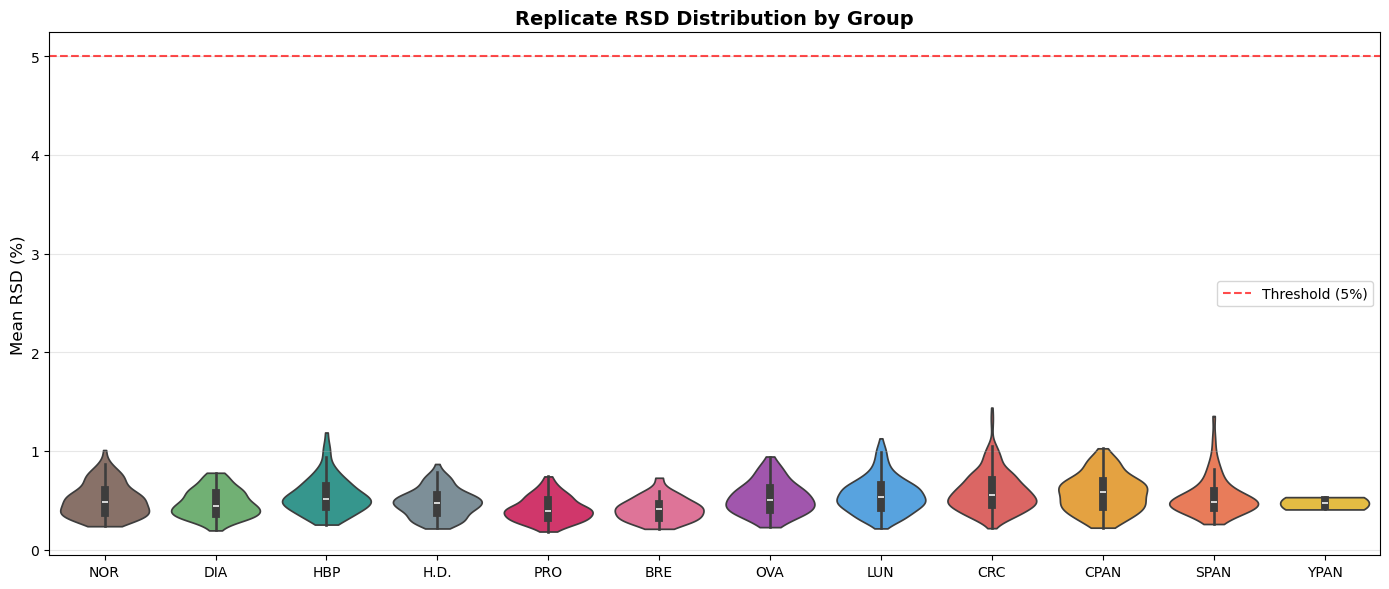

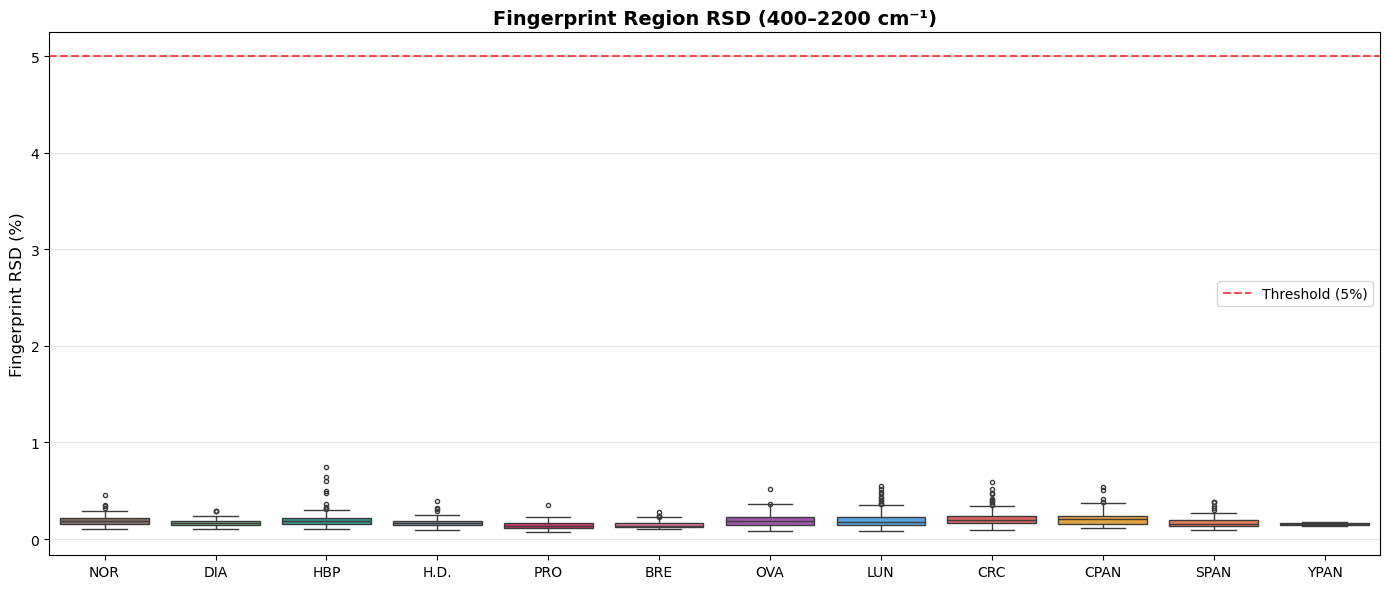

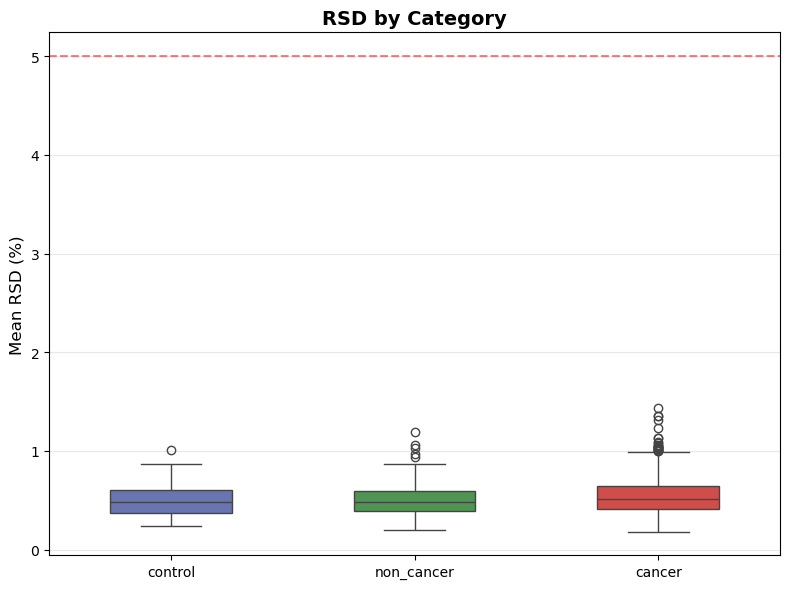

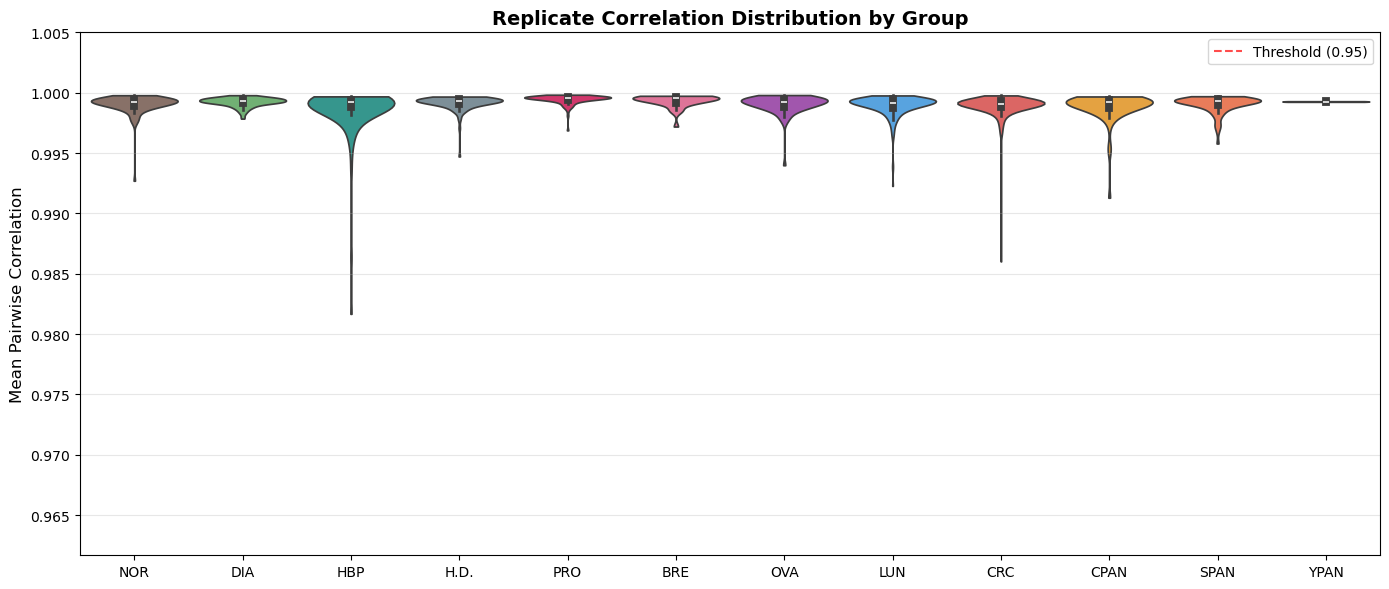

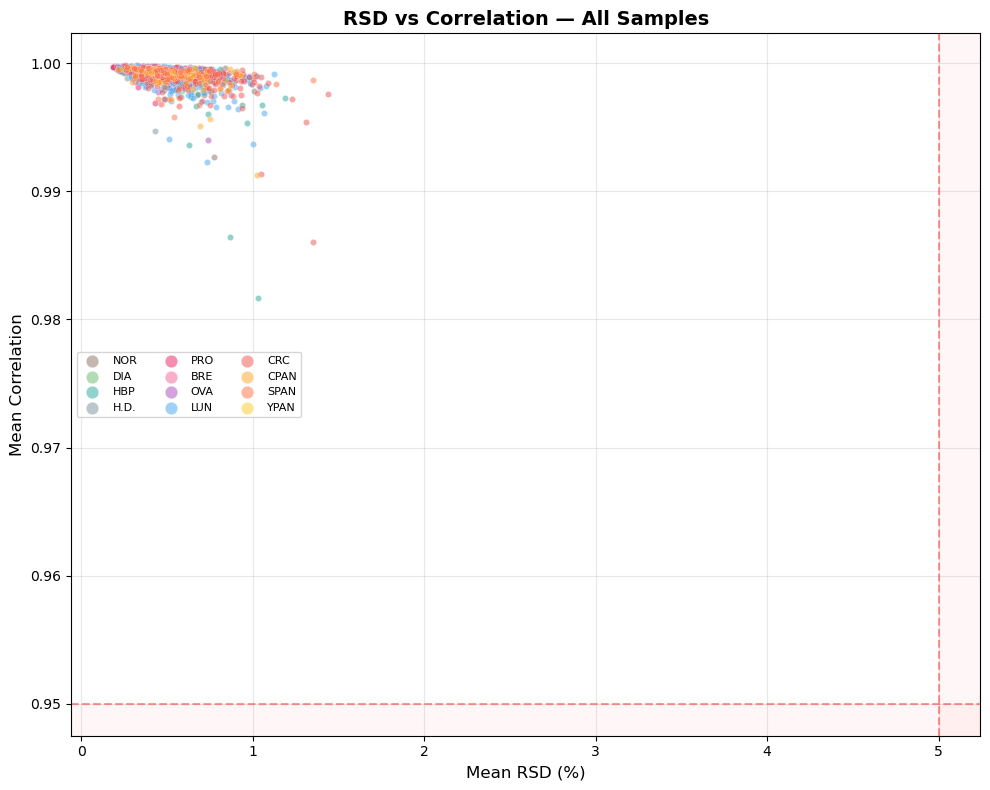

2026-02-25 14:58:39,032 - WARNING - No study type info, skipping


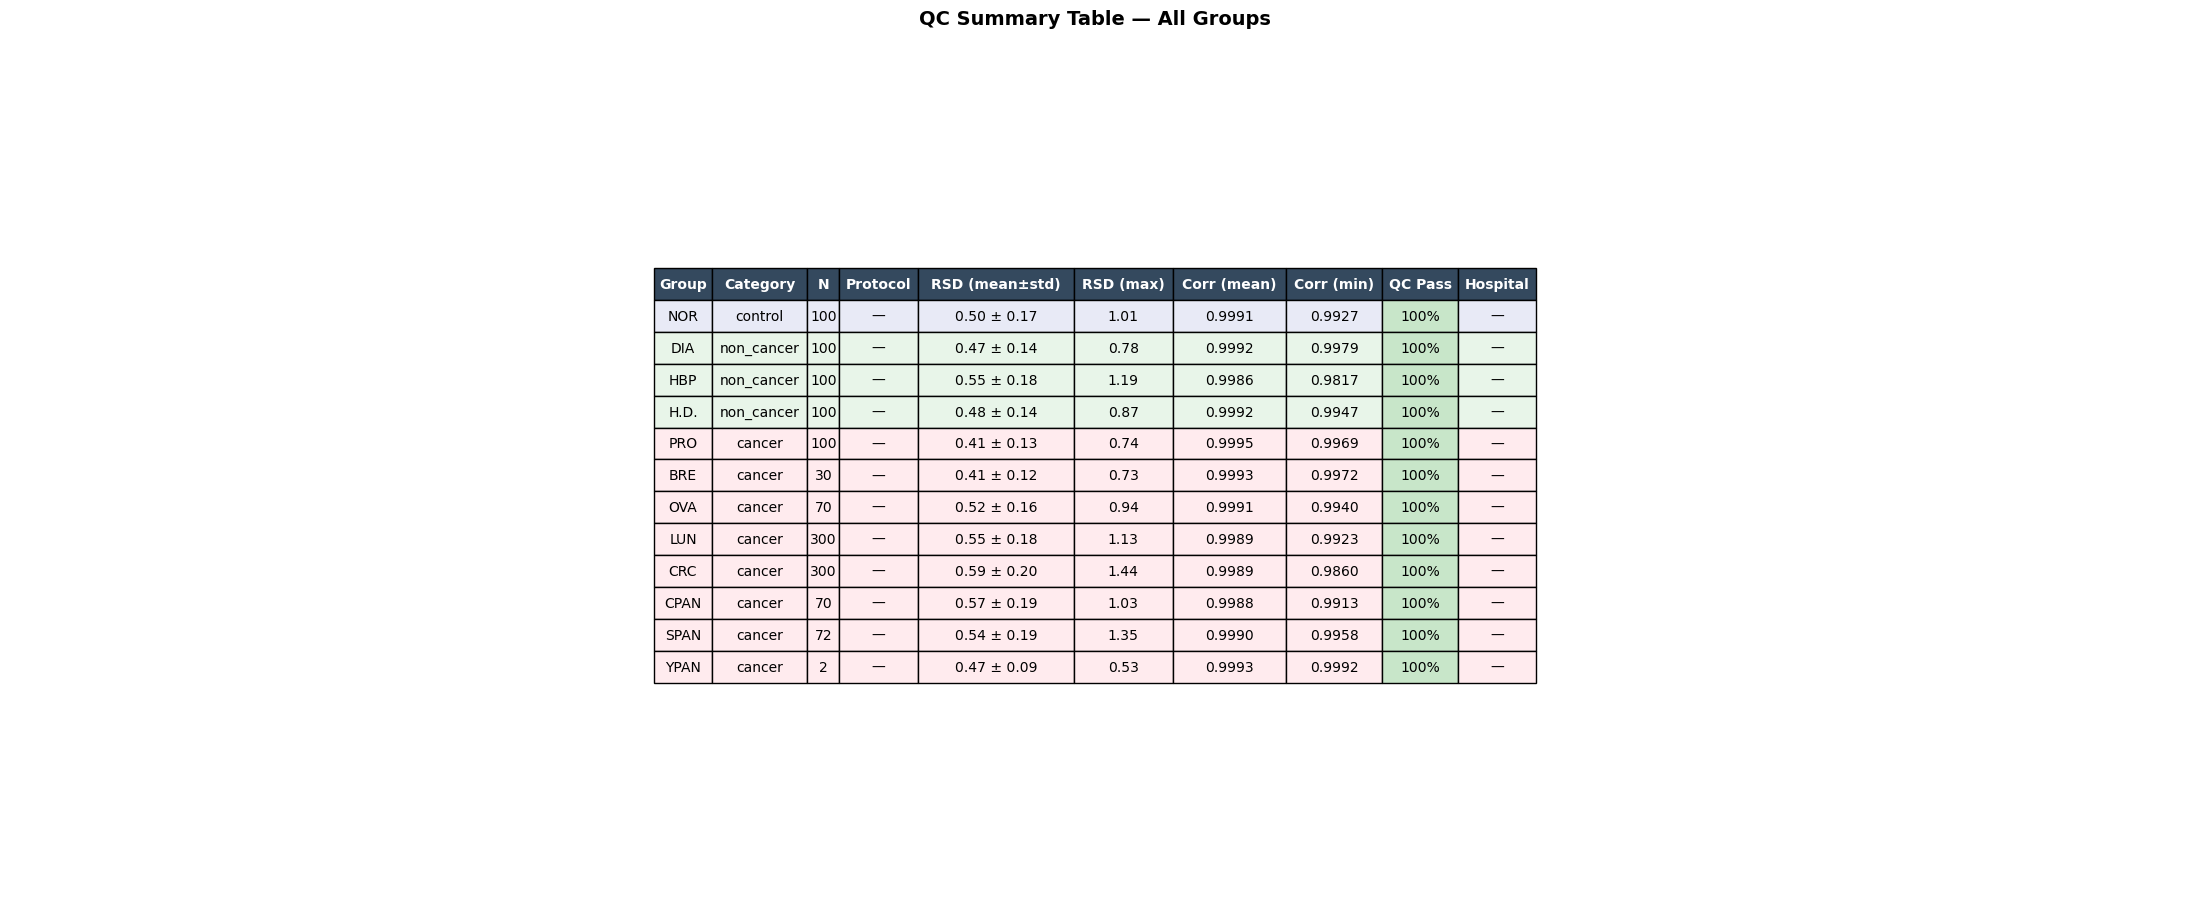

2026-02-25 14:58:40,110 - INFO - 
[5/7] Replicate figures...


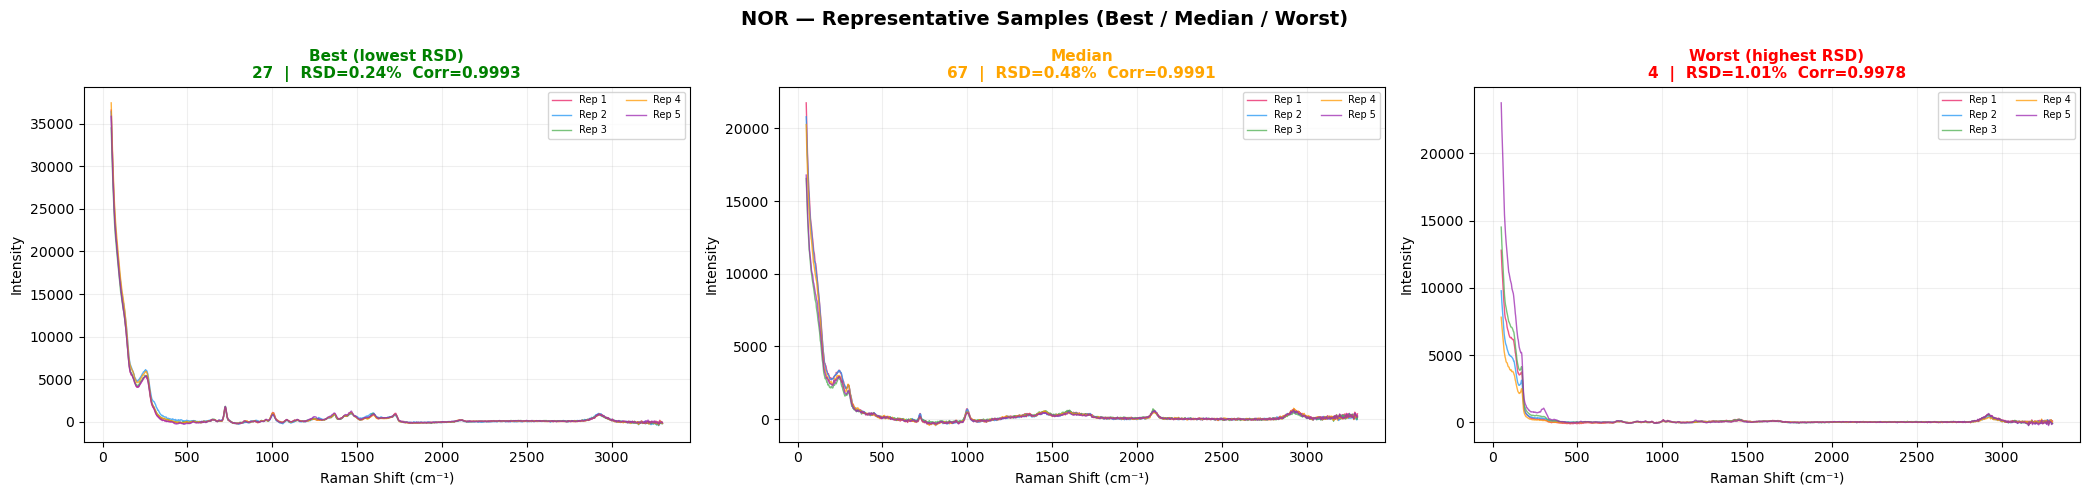

2026-02-25 14:58:42,216 - INFO -   NOR: saved


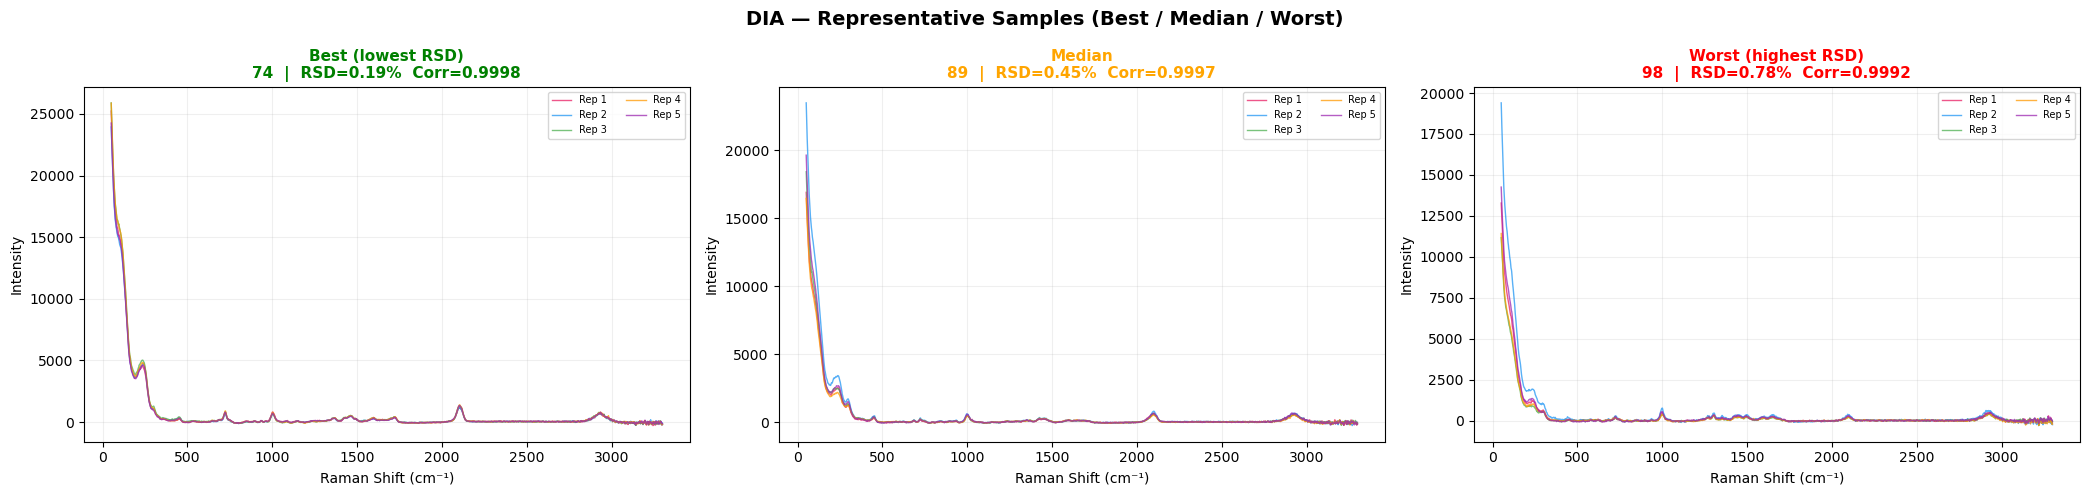

2026-02-25 14:58:43,244 - INFO -   DIA: saved


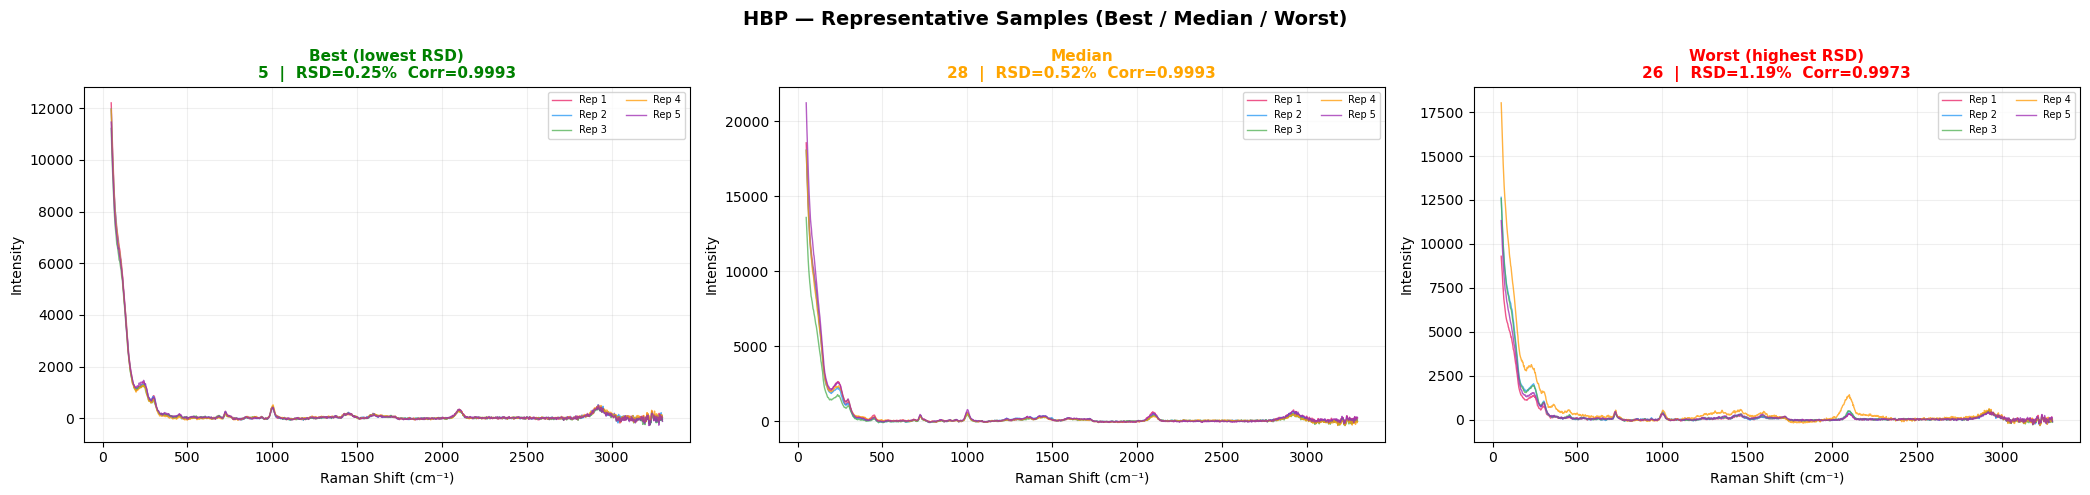

2026-02-25 14:58:44,466 - INFO -   HBP: saved


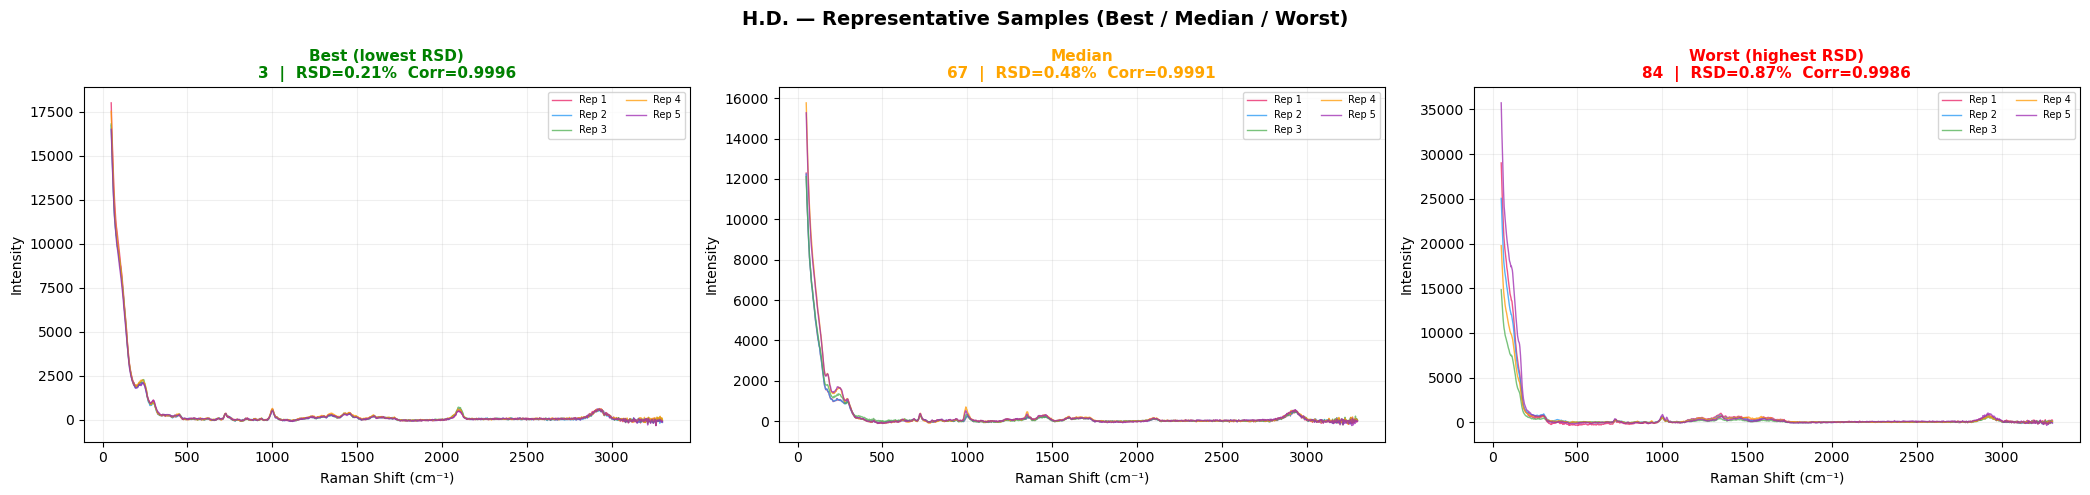

2026-02-25 14:58:45,885 - INFO -   H.D.: saved


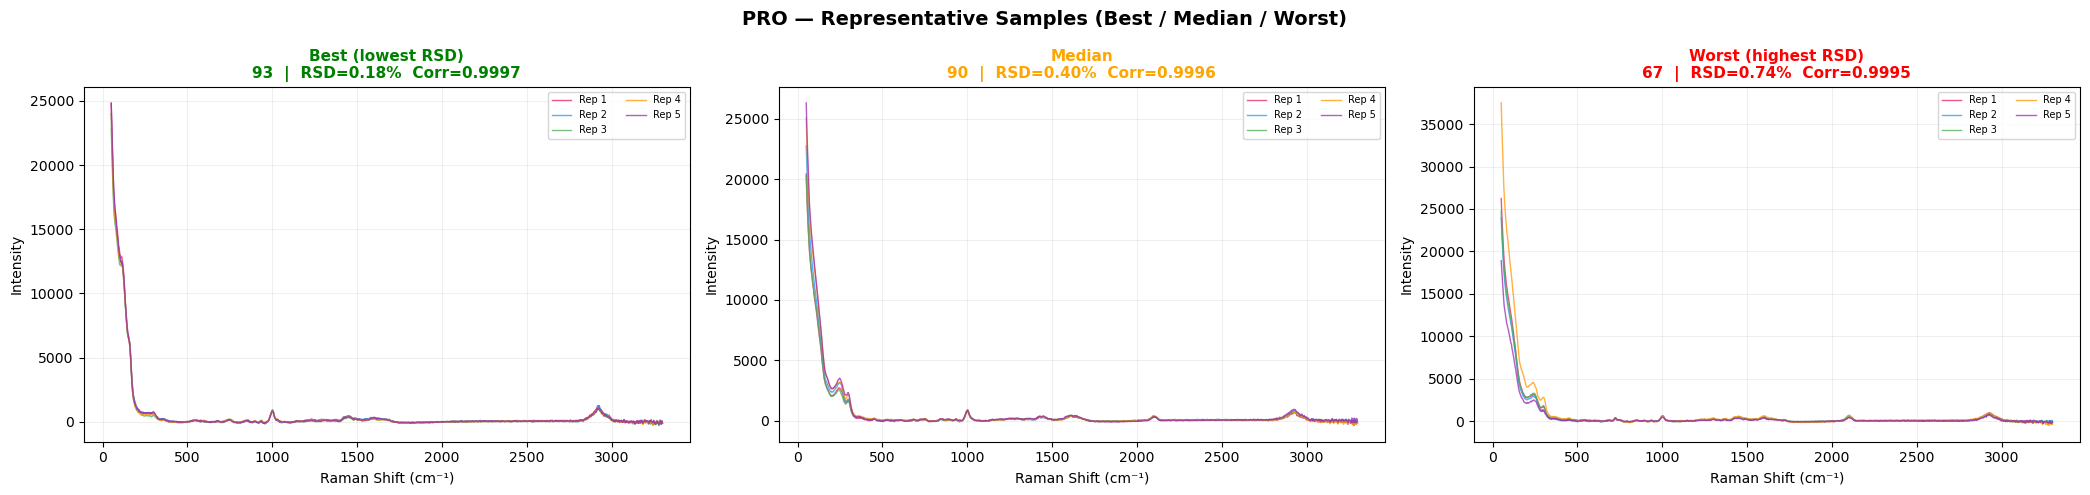

2026-02-25 14:58:46,968 - INFO -   PRO: saved


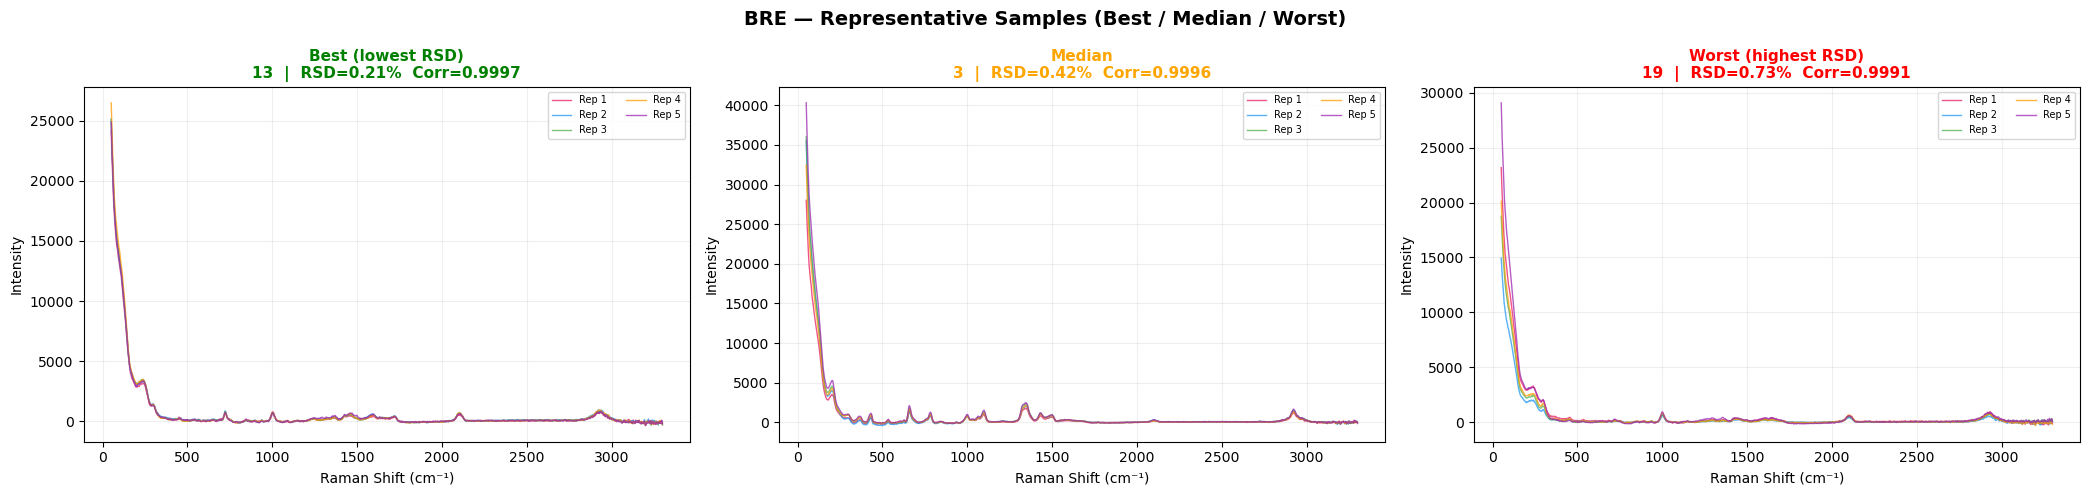

2026-02-25 14:58:48,388 - INFO -   BRE: saved


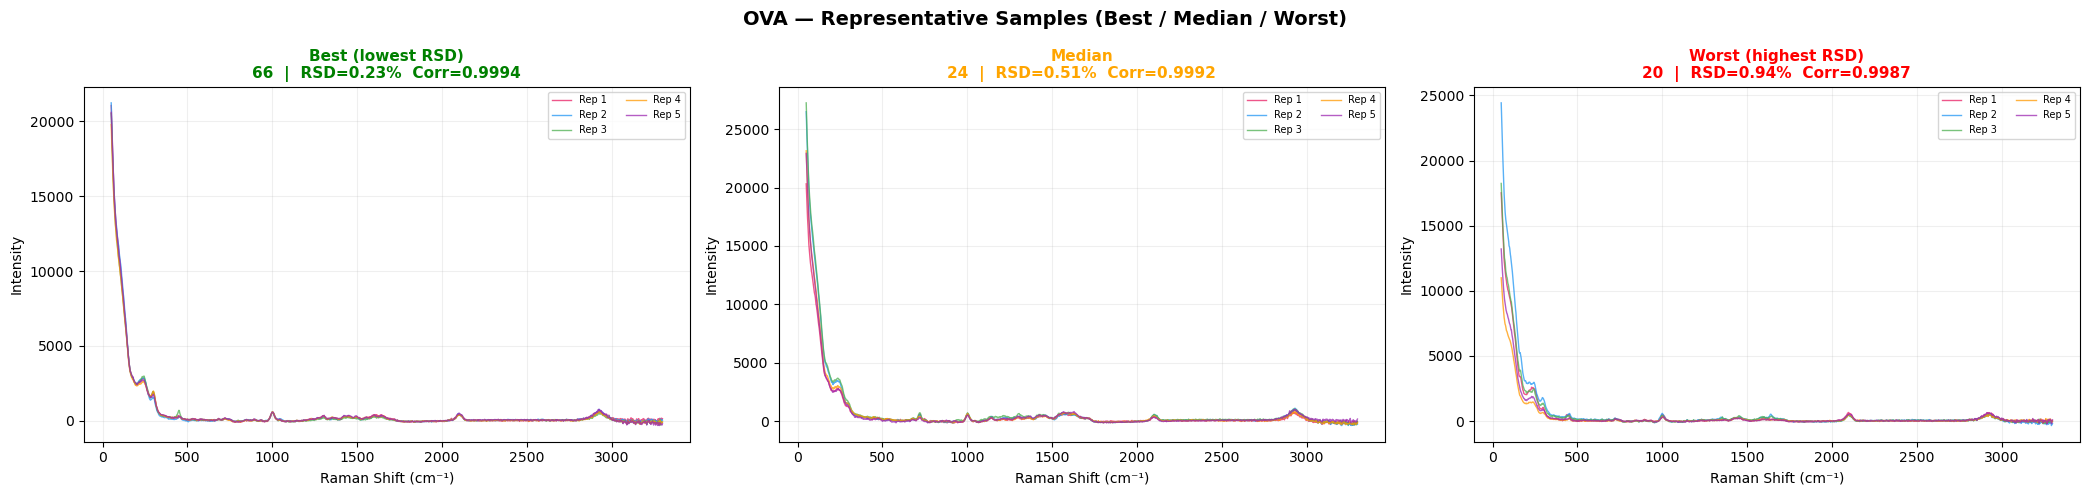

2026-02-25 14:58:49,483 - INFO -   OVA: saved


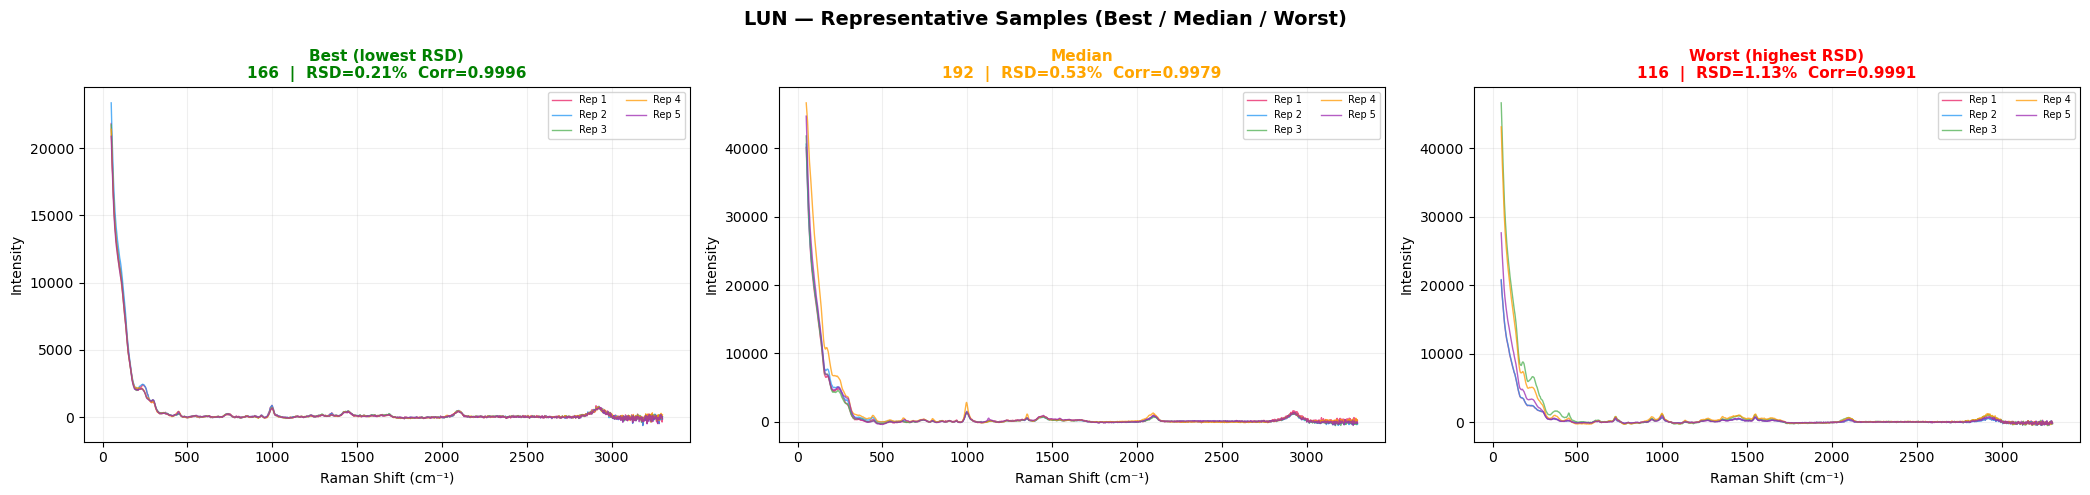

2026-02-25 14:58:50,675 - INFO -   LUN: saved


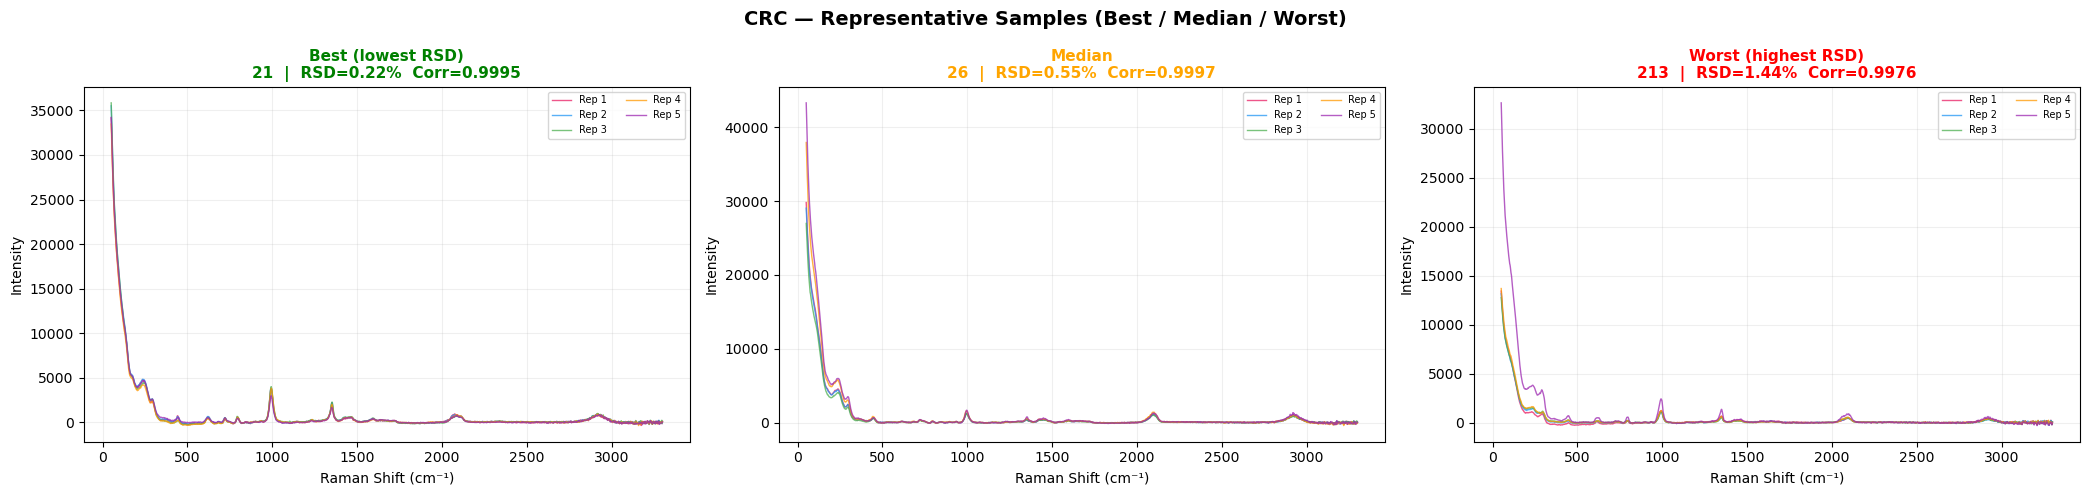

2026-02-25 14:58:51,782 - INFO -   CRC: saved


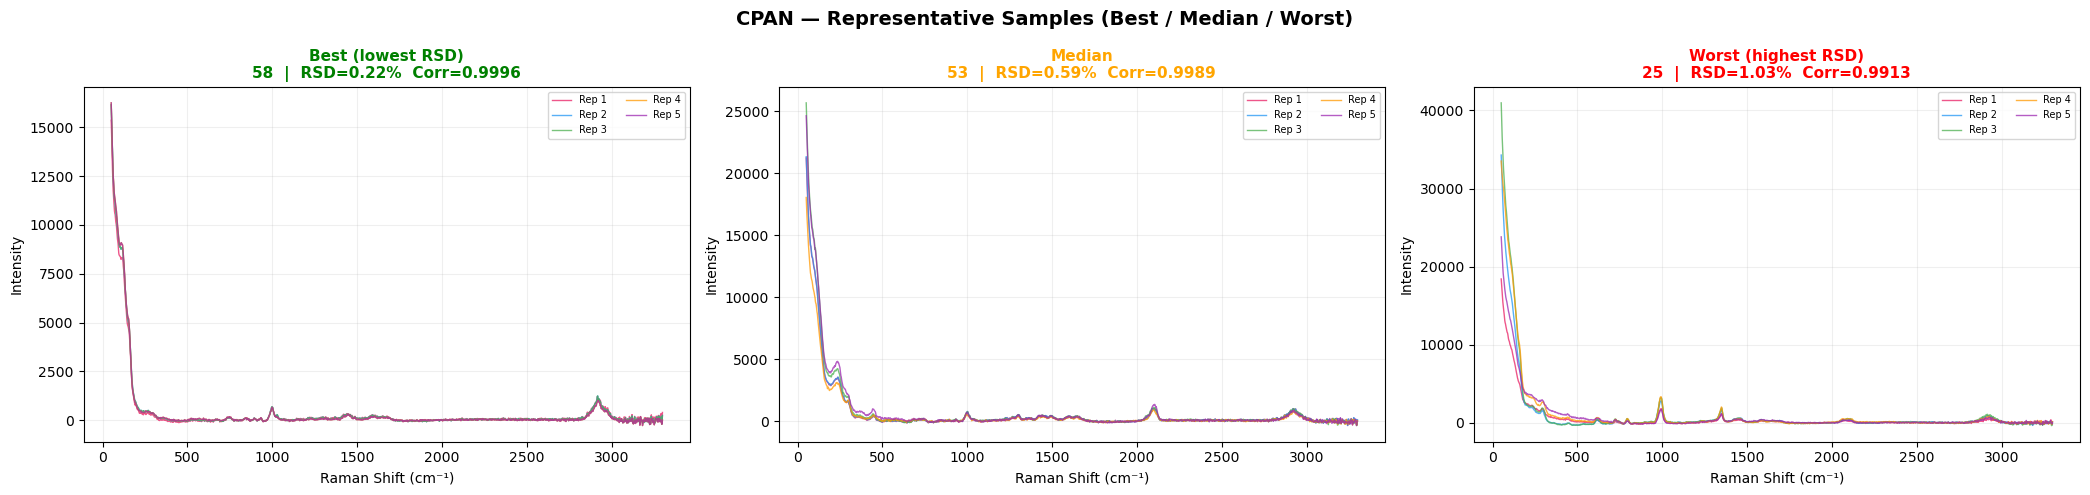

2026-02-25 14:58:52,946 - INFO -   CPAN: saved


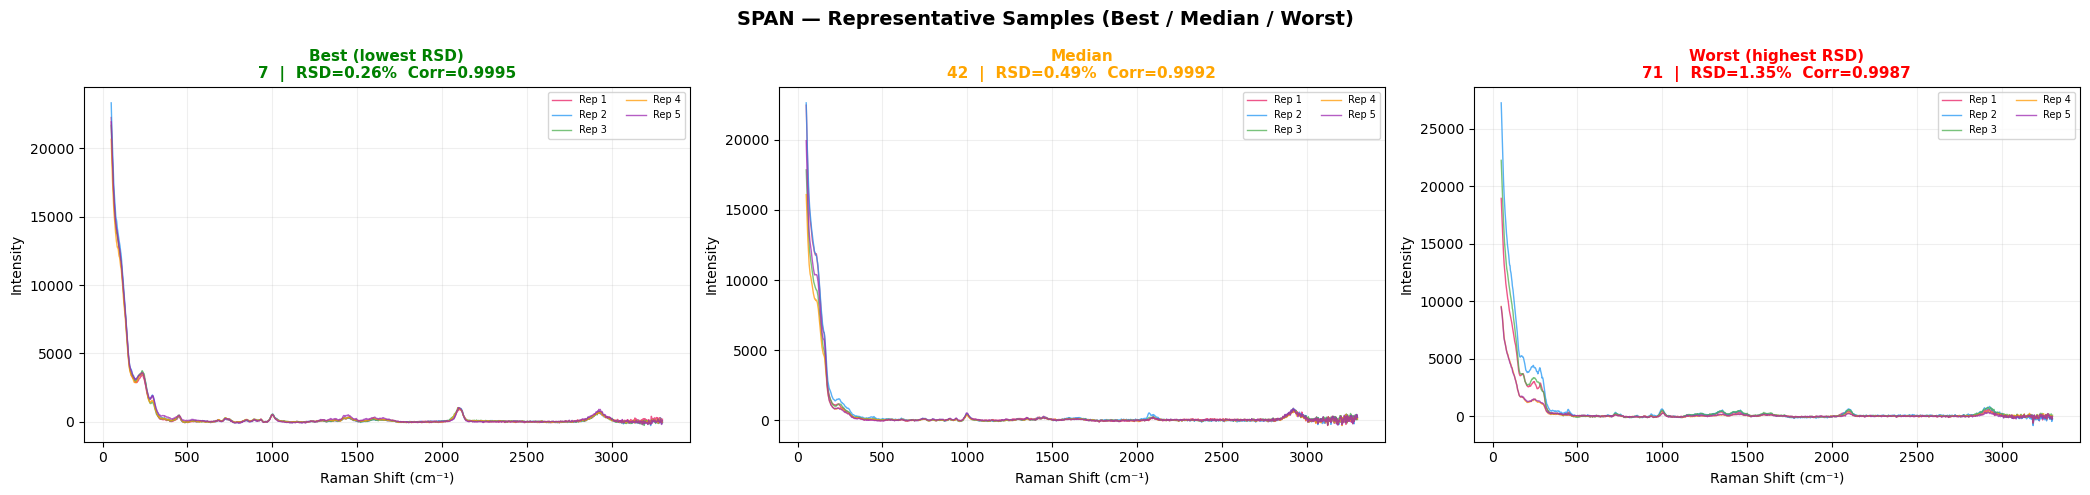

2026-02-25 14:58:54,000 - INFO -   SPAN: saved
2026-02-25 14:58:54,004 - WARNING -   YPAN: only 2 samples, skipping
2026-02-25 14:58:54,005 - INFO - Replicate figures → C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\results\qc_base_model\figures\replicate_figures
2026-02-25 14:58:54,023 - INFO - 
[6/7] Mean spectra figures...


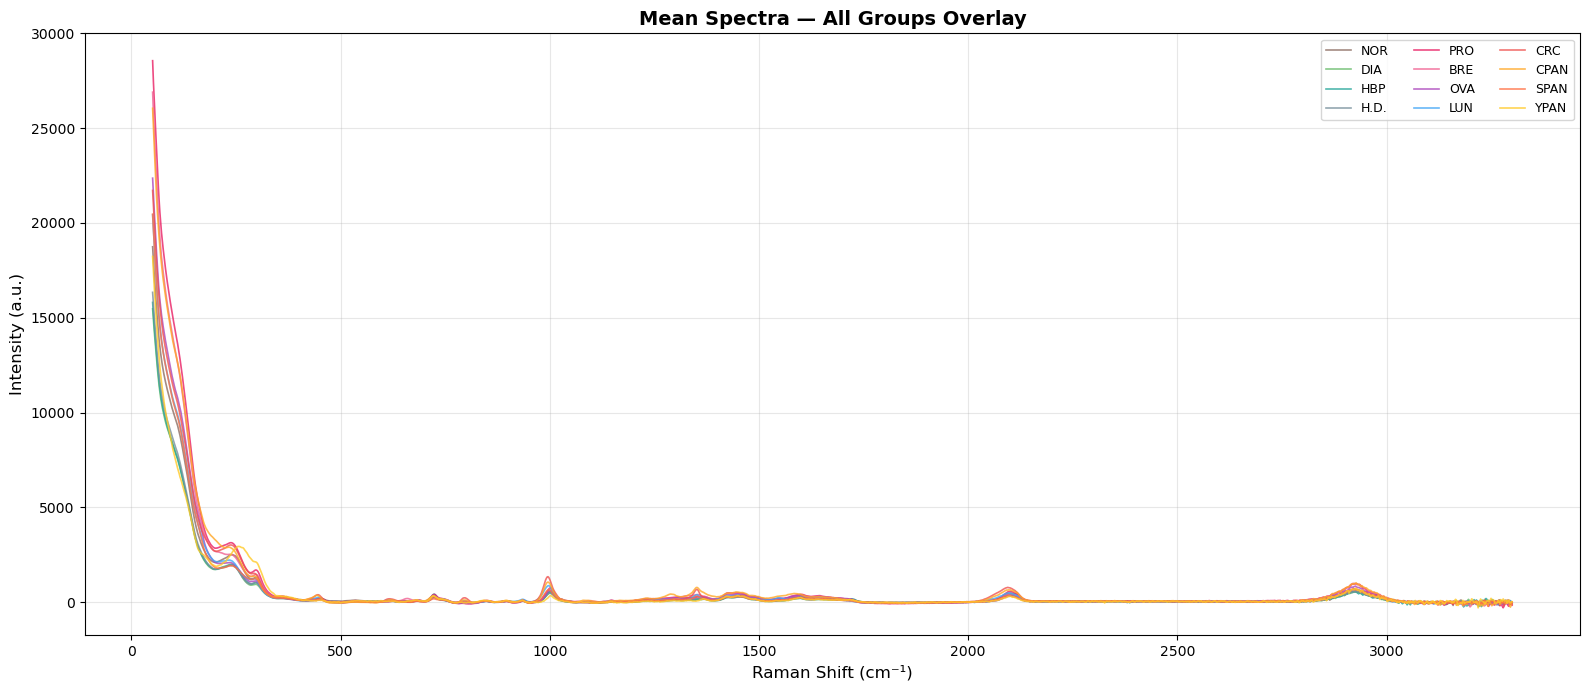

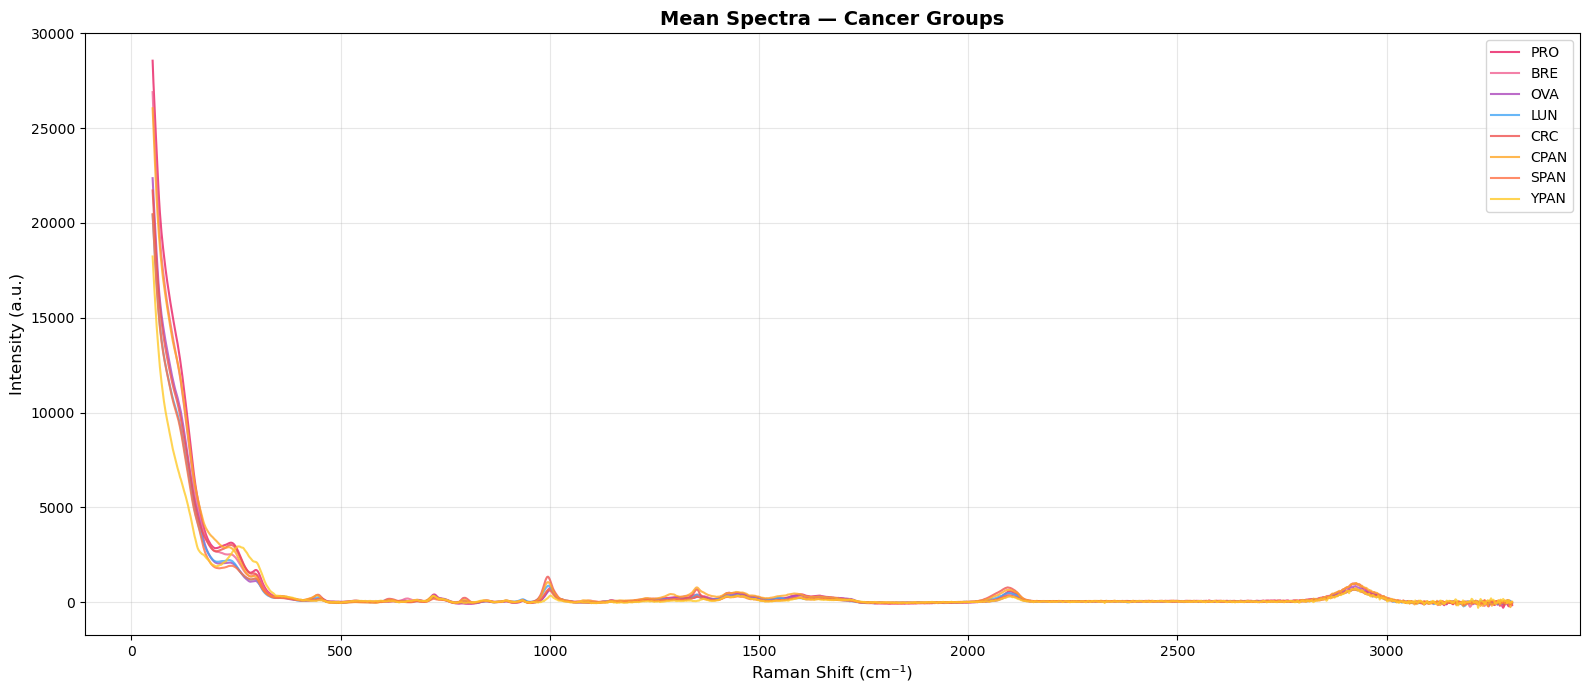

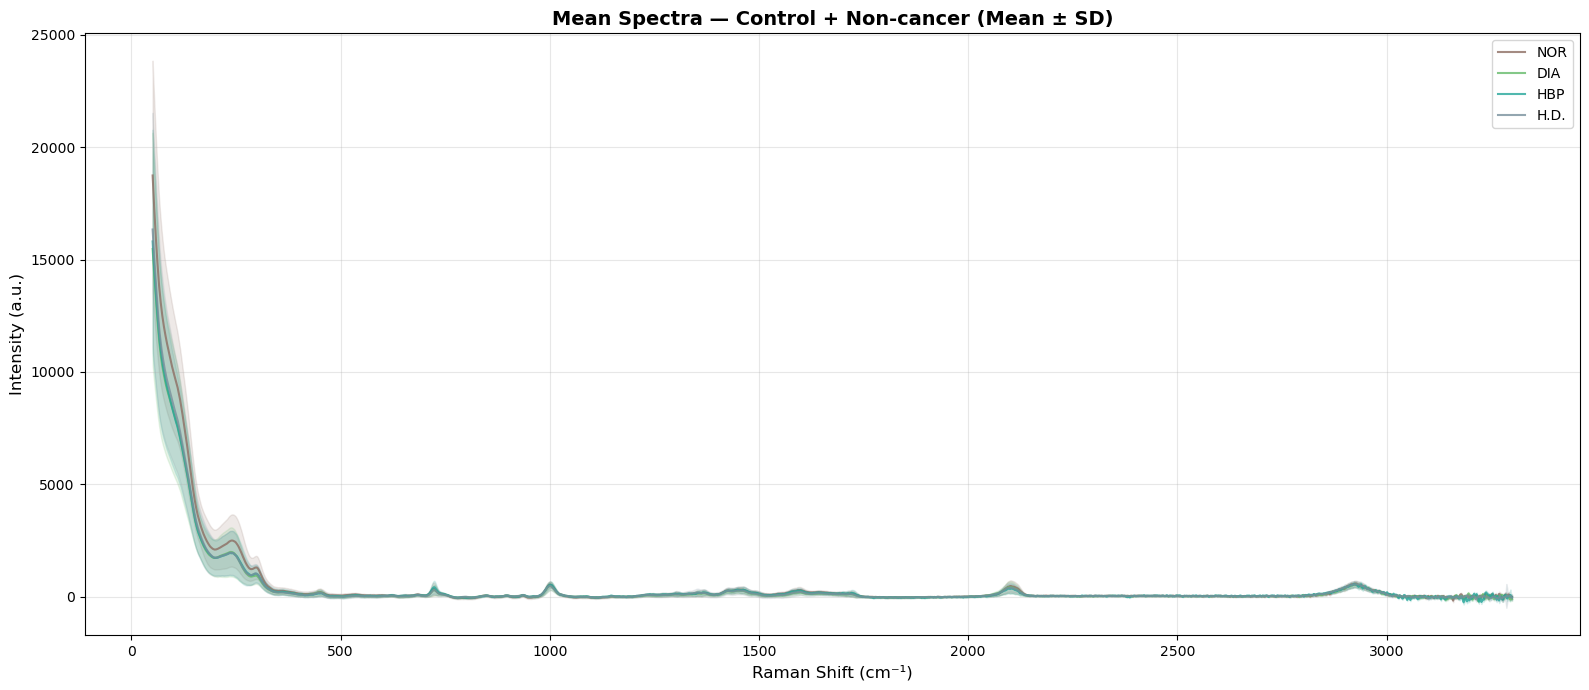

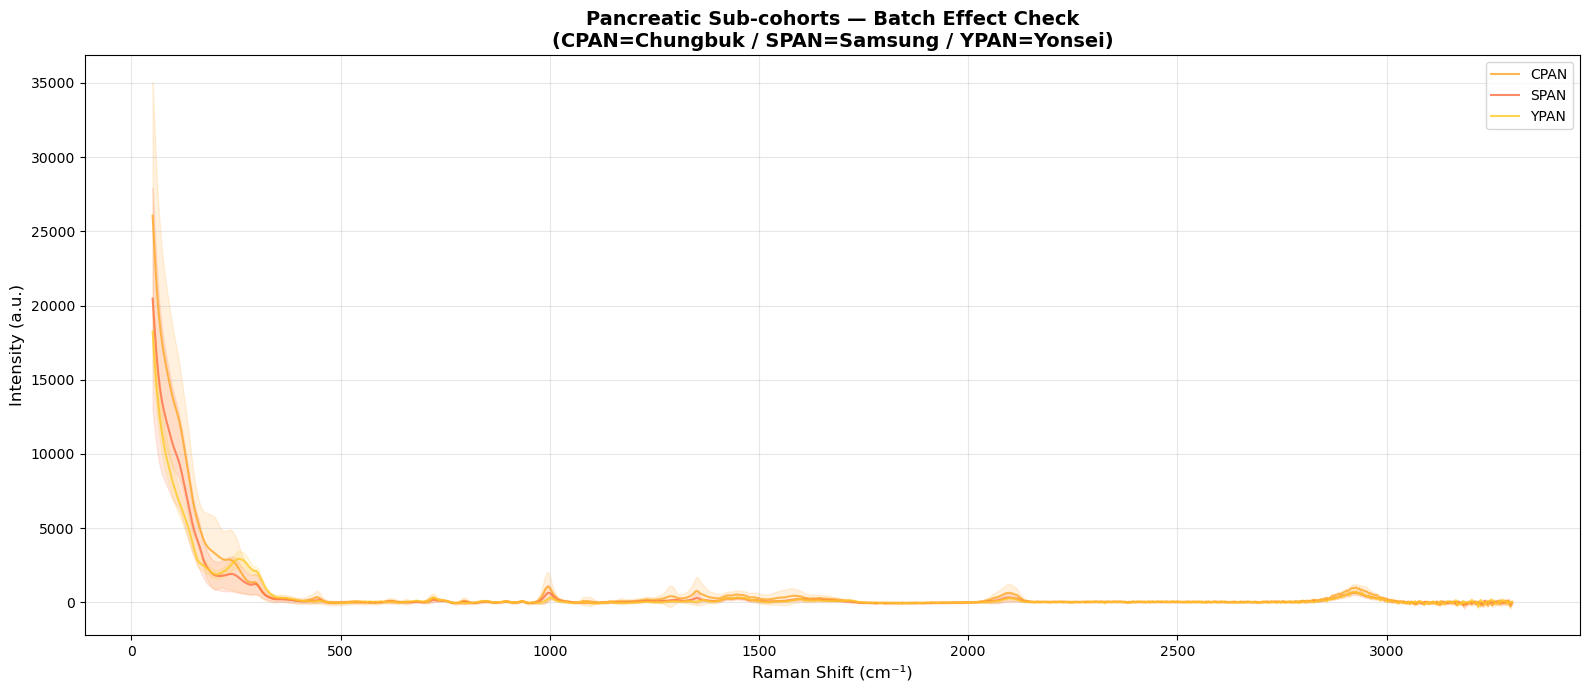

2026-02-25 14:58:58,348 - INFO - 
[7/7] Confounding & convergence figures...
2026-02-25 14:58:58,351 - WARNING - Only 1 hospital, skipping
2026-02-25 14:58:58,353 - WARNING - Only 1 protocol, skipping


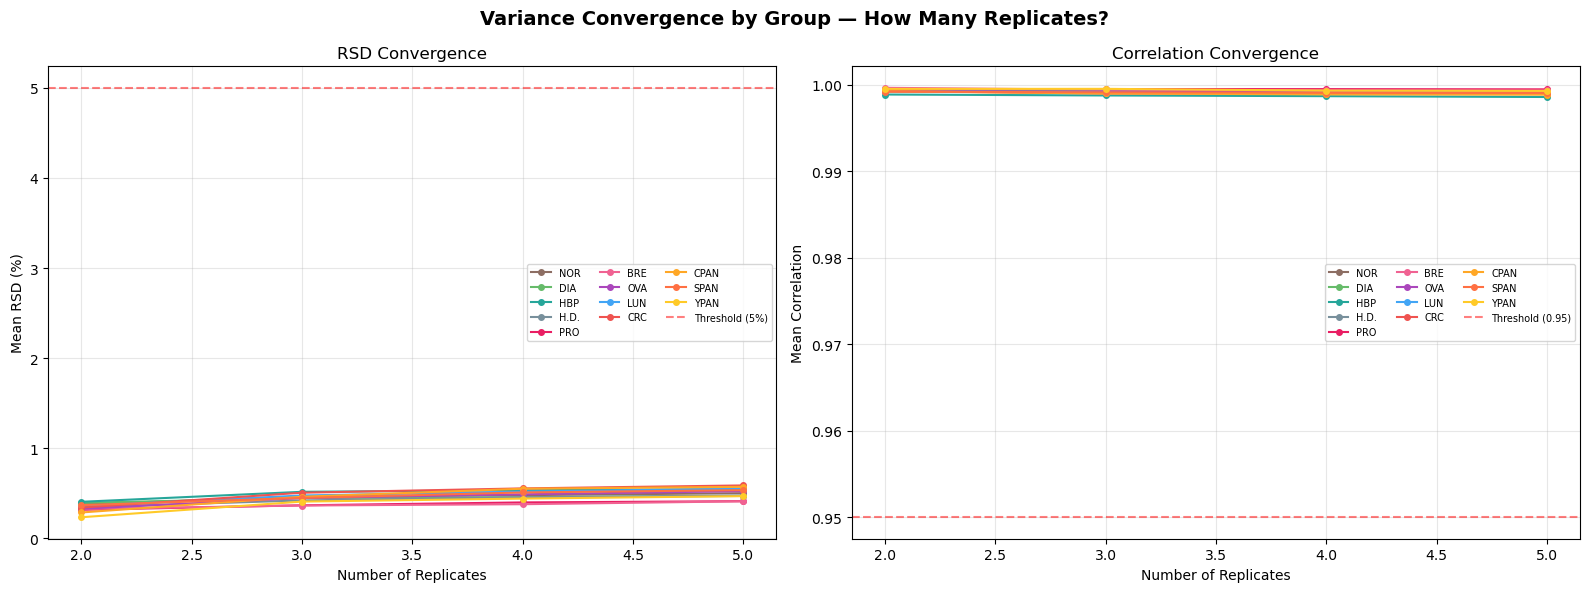

2026-02-25 14:59:02,231 - INFO - 
2026-02-25 14:59:02,233 - INFO - QC Pipeline Complete!
2026-02-25 14:59:02,233 - INFO - Results: C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\results\qc_base_model
2026-02-25 14:59:02,234 - INFO - Figures: C:\Users\YoonInsu_HealthCare_\OneDrive - solum\바탕 화면\SERS-AI\results\qc_base_model\figures
2026-02-25 14:59:02,234 - INFO - ============================================================


In [2]:
"""
============================================================
Base Model QC Pipeline — Group-level Comparison
============================================================
Equipment: Thermo DXR3xi (single equipment)
Groups: 12 groups (7 cancer, 3 non-cancer, 1 control, 1 combined)

Usage (Jupyter):
    %run qc_base_model.py
    # or copy cells into notebook
============================================================
"""

import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sers.config import load_config, RAW_DATA_DIR, RESULTS_DIR, FIG_DIR
from sers.io import find_spectra, read_spectrum, parse_filename, make_common_grid
from sers.qc import (
    run_qc_pipeline,
    calculate_variance_convergence,
    interpolate_to_grid,
)

# ============================================================
# Setup
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler("qc_base_model.log"),
    ],
)
logger = logging.getLogger(__name__)

# Output directories
QC_DIR = RESULTS_DIR / "qc_base_model"
QC_DIR.mkdir(parents=True, exist_ok=True)
QC_FIG_DIR = QC_DIR / "figures"
QC_FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Color & Style Configuration
# ============================================================
GROUP_COLORS = {
    "PRO": "#E91E63", "BRE": "#F06292", "OVA": "#AB47BC",
    "LUN": "#42A5F5", "CRC": "#EF5350",
    "CPAN": "#FFA726", "SPAN": "#FF7043", "YPAN": "#FFCA28",
    "DIA": "#66BB6A", "HBP": "#26A69A", "H.D.": "#78909C",
    "NOR": "#8D6E63",
}

CATEGORY_COLORS = {
    "cancer": "#E53935",
    "non_cancer": "#43A047",
    "control": "#5C6BC0",
}

GROUP_ORDER = [
    "NOR", "DIA", "HBP", "H.D.",
    "PRO", "BRE", "OVA", "LUN", "CRC",
    "CPAN", "SPAN", "YPAN",
]

CATEGORY_MAP = {
    "NOR": "control", "DIA": "non_cancer", "HBP": "non_cancer", "H.D.": "non_cancer",
    "PRO": "cancer", "BRE": "cancer", "OVA": "cancer", "LUN": "cancer", "CRC": "cancer",
    "CPAN": "cancer", "SPAN": "cancer", "YPAN": "cancer",
}

REPLICATE_COLORS = [
    "#E91E63", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0",
    "#00BCD4", "#FF5722", "#795548", "#607D8B", "#CDDC39",
]


# ============================================================
# 1. Data Loading
# ============================================================
def load_all_spectra(config):
    """Load all spectra from all group folders."""
    data_dir = Path(RAW_DATA_DIR)
    folder_map = config.folder_to_group

    all_spectra = {}
    metadata_rows = []

    logger.info(f"Data directory: {data_dir}")
    logger.info(f"Groups to load: {len(folder_map)}")

    for folder_name, group_code in folder_map.items():
        folder_path = data_dir / folder_name

        if not folder_path.exists():
            logger.warning(f"  ⚠ Folder not found: {folder_name}")
            continue

        files = list(find_spectra(folder_path, pattern="*.csv"))
        if not files:
            files = list(find_spectra(folder_path, pattern="*.CSV"))

        logger.info(f"  {group_code}: {len(files)} files in '{folder_name}'")

        loaded = 0
        for fpath in files:
            try:
                spec_id = parse_filename(fpath, fallback_group=group_code)
                x, y = read_spectrum(fpath)

                key = (spec_id.group, spec_id.sample_id, spec_id.replicate)
                all_spectra[key] = (x, y)

                metadata_rows.append({
                    "group": spec_id.group,
                    "sample_id": spec_id.sample_id,
                    "replicate": spec_id.replicate,
                    "file": fpath.name,
                    "folder": folder_name,
                    "n_points": len(x),
                    "x_min": x.min(),
                    "x_max": x.max(),
                })
                loaded += 1

            except Exception as e:
                logger.warning(f"    Failed: {fpath.name} — {e}")

        logger.info(f"    Loaded: {loaded}/{len(files)}")

    meta_df = pd.DataFrame(metadata_rows)
    logger.info(f"\nTotal loaded: {len(all_spectra)} spectra from {meta_df['sample_id'].nunique()} samples")

    return all_spectra, meta_df


# ============================================================
# 2. Group-level QC Execution
# ============================================================
def run_group_qc(all_spectra, common_grid, config):
    """Run QC pipeline per group and collect results."""

    group_spectra = {}
    for (group, sid, rep), (x, y) in all_spectra.items():
        if group not in group_spectra:
            group_spectra[group] = {}
        group_spectra[group][(group, sid, rep)] = (x, y)

    all_qc_stats = []
    all_gate_dfs = []
    all_failures = []
    group_summaries = {}

    for group in GROUP_ORDER:
        if group not in group_spectra:
            logger.warning(f"  ⚠ No data for group {group}")
            continue

        spectra = group_spectra[group]
        n_spectra = len(spectra)
        n_samples = len(set(sid for (_, sid, _) in spectra.keys()))

        logger.info(f"\n{'='*50}")
        logger.info(f"  QC: {group} — {n_samples} samples, {n_spectra} spectra")
        logger.info(f"{'='*50}")

        gate_df, qc_stats, failures, group_summary = run_qc_pipeline(
            spectra,
            common_grid,
            qc_config=config.qc,
            save_report=str(QC_DIR / f"qc_report_{group}.txt"),
            save_json=str(QC_DIR / f"qc_report_{group}.json"),
        )

        if len(gate_df) > 0:
            all_gate_dfs.append(gate_df)
        if len(qc_stats) > 0:
            all_qc_stats.append(qc_stats)
        if len(failures) > 0:
            all_failures.append(failures)

        group_summaries[group] = group_summary

    combined_qc = pd.concat(all_qc_stats, ignore_index=True) if all_qc_stats else pd.DataFrame()
    combined_gate = pd.concat(all_gate_dfs, ignore_index=True) if all_gate_dfs else pd.DataFrame()
    combined_failures = pd.concat(all_failures, ignore_index=True) if all_failures else pd.DataFrame()

    return combined_qc, combined_gate, combined_failures, group_summaries


# ============================================================
# Helpers
# ============================================================
def _active_groups(qc_stats):
    return [g for g in GROUP_ORDER if g in qc_stats["group"].unique()]


def _palette_for(groups):
    return [GROUP_COLORS.get(g, "#888") for g in groups]


# ============================================================
# 3. Sample Count
# ============================================================
def plot_sample_count(qc_stats, output_dir):
    groups = _active_groups(qc_stats)
    palette = _palette_for(groups)

    fig, ax = plt.subplots(figsize=(12, 5))
    counts = qc_stats.groupby("group")["sample_id"].count().reindex(groups).fillna(0)
    ax.bar(range(len(groups)), counts.values, color=palette, edgecolor="white", linewidth=0.5)

    for i, g in enumerate(groups):
        cat = CATEGORY_MAP.get(g, "control")
        ax.plot(i, -counts.max() * 0.03, "s", color=CATEGORY_COLORS[cat], markersize=10, clip_on=False)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel("N Samples", fontsize=12)
    ax.set_title("Sample Count by Group", fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.01, f"{int(v)}", ha="center", fontsize=9)

    plt.tight_layout()
    fig.savefig(output_dir / "01_sample_count.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 4. Intensity Gate
# ============================================================
def plot_intensity_gate(gate_df, output_dir):
    if len(gate_df) == 0 or "gate_pass" not in gate_df.columns:
        logger.warning("No gate data, skipping")
        return

    groups = [g for g in GROUP_ORDER if g in gate_df["group"].unique()]
    fig, ax = plt.subplots(figsize=(12, 5))
    gate_summary = gate_df.groupby("group")["gate_pass"].agg(["sum", "count"])
    gate_summary["fail"] = gate_summary["count"] - gate_summary["sum"]
    gate_summary = gate_summary.reindex(groups).fillna(0)

    x_pos = range(len(groups))
    ax.bar(x_pos, gate_summary["sum"], color="#4CAF50", alpha=0.8, label="Pass")
    ax.bar(x_pos, gate_summary["fail"], bottom=gate_summary["sum"], color="#F44336", alpha=0.8, label="Fail")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel("N Spectra", fontsize=12)
    ax.set_title("Intensity Gate — Level 0 (per spectrum)", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "02_intensity_gate.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 5. QC Pass Rate
# ============================================================
def plot_qc_pass_rate(qc_stats, output_dir):
    groups = _active_groups(qc_stats)
    palette = _palette_for(groups)

    fig, ax = plt.subplots(figsize=(12, 5))
    pass_rates = []
    for g in groups:
        grp = qc_stats[qc_stats["group"] == g]
        n_pass = ((grp["mean_rsd"] <= 5.0) & (grp["mean_corr"] >= 0.95)).sum()
        pass_rates.append(100 * n_pass / len(grp) if len(grp) > 0 else 0)

    ax.bar(range(len(groups)), pass_rates, color=palette, edgecolor="white", linewidth=0.5)
    ax.axhline(y=80, color="orange", ls="--", alpha=0.7, label="80%")
    ax.axhline(y=95, color="green", ls="--", alpha=0.7, label="95%")

    for i, v in enumerate(pass_rates):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9,
                color="green" if v >= 95 else ("orange" if v >= 80 else "red"))

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel("Pass Rate (%)", fontsize=12)
    ax.set_ylim(0, 108)
    ax.set_title("QC Pass Rate (RSD < 5% & Corr > 0.95)", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "03_qc_pass_rate.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 6. RSD Violin
# ============================================================
def plot_rsd_violin(qc_stats, output_dir):
    groups = _active_groups(qc_stats)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.violinplot(
        data=qc_stats, x="group", y="mean_rsd",
        hue="group", order=groups, hue_order=groups,
        palette=GROUP_COLORS, ax=ax, inner="box", cut=0,
        density_norm="width", legend=False,
    )
    ax.axhline(y=5.0, color="red", ls="--", alpha=0.7, label="Threshold (5%)")
    ax.set_title("Replicate RSD Distribution by Group", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean RSD (%)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "04_rsd_violin.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 7. Fingerprint RSD
# ============================================================
def plot_rsd_fingerprint(qc_stats, output_dir):
    if "rsd_fingerprint" not in qc_stats.columns:
        return
    groups = _active_groups(qc_stats)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(
        data=qc_stats, x="group", y="rsd_fingerprint",
        hue="group", order=groups, hue_order=groups,
        palette=GROUP_COLORS, ax=ax, fliersize=3, legend=False,
    )
    ax.axhline(y=5.0, color="red", ls="--", alpha=0.7, label="Threshold (5%)")
    ax.set_title("Fingerprint Region RSD (400–2200 cm⁻¹)", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Fingerprint RSD (%)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "05_rsd_fingerprint.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 8. RSD by Category
# ============================================================
def plot_rsd_by_category(qc_stats, output_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    qc_cat = qc_stats.copy()
    qc_cat["category"] = qc_cat["group"].map(CATEGORY_MAP)
    cat_order = ["control", "non_cancer", "cancer"]

    sns.boxplot(
        data=qc_cat, x="category", y="mean_rsd",
        hue="category", order=cat_order, hue_order=cat_order,
        palette=CATEGORY_COLORS, ax=ax, width=0.5, legend=False,
    )
    ax.axhline(y=5.0, color="red", ls="--", alpha=0.5)
    ax.set_title("RSD by Category", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean RSD (%)", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "06_rsd_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 9. Correlation Violin
# ============================================================
def plot_corr_violin(qc_stats, output_dir):
    groups = _active_groups(qc_stats)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.violinplot(
        data=qc_stats, x="group", y="mean_corr",
        hue="group", order=groups, hue_order=groups,
        palette=GROUP_COLORS, ax=ax, inner="box", cut=0,
        density_norm="width", legend=False,
    )
    ax.axhline(y=0.95, color="red", ls="--", alpha=0.7, label="Threshold (0.95)")
    ax.set_title("Replicate Correlation Distribution by Group", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Pairwise Correlation", fontsize=12)
    ax.legend(fontsize=10)
    ax.set_ylim(max(0.80, qc_stats["mean_corr"].min() - 0.02), 1.005)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "07_corr_violin.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 10. RSD vs Correlation Scatter
# ============================================================
def plot_rsd_vs_corr(qc_stats, output_dir):
    groups = _active_groups(qc_stats)

    fig, ax = plt.subplots(figsize=(10, 8))
    for g in groups:
        mask = qc_stats["group"] == g
        ax.scatter(
            qc_stats[mask]["mean_rsd"], qc_stats[mask]["mean_corr"],
            c=GROUP_COLORS.get(g, "#888"), label=g, alpha=0.5, s=20,
            edgecolors="white", linewidth=0.3,
        )
    ax.axvline(x=5.0, color="red", ls="--", alpha=0.4)
    ax.axhline(y=0.95, color="red", ls="--", alpha=0.4)
    ax.set_xlabel("Mean RSD (%)", fontsize=12)
    ax.set_ylabel("Mean Correlation", fontsize=12)
    ax.set_title("RSD vs Correlation — All Samples", fontsize=14, fontweight="bold")
    ax.legend(fontsize=8, ncol=3, markerscale=2)

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.axvspan(5.0, xlim[1], alpha=0.03, color="red")
    ax.axhspan(ylim[0], 0.95, alpha=0.03, color="red")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "08_rsd_vs_corr_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 11. Correlation by Study Type
# ============================================================
def plot_corr_by_study_type(qc_stats, group_meta, output_dir):
    study_map = {}
    for g, meta in group_meta.items():
        if isinstance(meta, dict):
            study_map[g] = meta.get("study_type", "unknown")

    qc_ext = qc_stats.copy()
    qc_ext["study_type"] = qc_ext["group"].map(study_map)
    valid = qc_ext[qc_ext["study_type"].isin(["retrospective", "prospective"])]

    if len(valid) == 0:
        logger.warning("No study type info, skipping")
        return

    fig, ax = plt.subplots(figsize=(8, 6))
    study_order = ["retrospective", "prospective"]
    sns.boxplot(
        data=valid, x="study_type", y="mean_corr",
        hue="study_type", order=study_order, hue_order=study_order,
        palette=["#42A5F5", "#FF7043"], ax=ax, width=0.5, legend=False,
    )
    ax.axhline(y=0.95, color="red", ls="--", alpha=0.5)
    ax.set_title("Correlation: Retrospective vs Prospective\n(Batch Effect Check)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Correlation", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "09_corr_by_study_type.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 12. QC Summary Table
# ============================================================
def plot_qc_summary_table(qc_stats, group_meta, output_dir):
    groups = _active_groups(qc_stats)

    fig, ax = plt.subplots(figsize=(22, max(5, len(groups) * 0.6 + 2)))
    ax.axis("off")

    table_data = []
    for g in groups:
        grp = qc_stats[qc_stats["group"] == g]
        if len(grp) == 0:
            continue

        n = len(grp)
        cat = CATEGORY_MAP.get(g, "?")
        rsd_m = grp["mean_rsd"].mean()
        rsd_s = grp["mean_rsd"].std()
        rsd_mx = grp["mean_rsd"].max()
        corr_m = grp["mean_corr"].mean()
        corr_mn = grp["mean_corr"].min()

        hospital = "—"
        protocol = "—"
        if g in group_meta and isinstance(group_meta[g], dict):
            h = group_meta[g].get("hospital", "—")
            hospital = h[:28] + "…" if len(h) > 28 else h
            protocol = group_meta[g].get("protocol", "—")

        n_pass = ((grp["mean_rsd"] <= 5.0) & (grp["mean_corr"] >= 0.95)).sum()
        pr = 100 * n_pass / n

        table_data.append([
            g, cat, n, protocol,
            f"{rsd_m:.2f} ± {rsd_s:.2f}", f"{rsd_mx:.2f}",
            f"{corr_m:.4f}", f"{corr_mn:.4f}",
            f"{pr:.0f}%", hospital,
        ])

    col_labels = [
        "Group", "Category", "N", "Protocol",
        "RSD (mean±std)", "RSD (max)",
        "Corr (mean)", "Corr (min)",
        "QC Pass", "Hospital",
    ]

    table = ax.table(cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(range(len(col_labels)))
    table.scale(1, 1.6)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#34495e")
        table[0, j].set_text_props(color="white", fontweight="bold")

    qc_pass_col = 8
    for i, row_data in enumerate(table_data):
        cat = row_data[1]
        bg = {"cancer": "#FFEBEE", "non_cancer": "#E8F5E9", "control": "#E8EAF6"}.get(cat, "#FFF")
        for j in range(len(col_labels)):
            table[i + 1, j].set_facecolor(bg)

        pass_val = float(row_data[qc_pass_col].replace("%", ""))
        if pass_val >= 95:
            table[i + 1, qc_pass_col].set_facecolor("#C8E6C9")
        elif pass_val >= 80:
            table[i + 1, qc_pass_col].set_facecolor("#FFF9C4")
        else:
            table[i + 1, qc_pass_col].set_facecolor("#FFCDD2")

    ax.set_title("QC Summary Table — All Groups", fontsize=14, fontweight="bold", pad=20)

    plt.tight_layout()
    fig.savefig(output_dir / "10_qc_summary_table.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 13. Replicate Best / Median / Worst (per group)
# ============================================================
def plot_replicate_comparison(all_spectra, common_grid, qc_stats, output_dir):
    rep_fig_dir = output_dir / "replicate_figures"
    rep_fig_dir.mkdir(parents=True, exist_ok=True)

    samples = {}
    for (group, sid, rep), (x, y) in all_spectra.items():
        key = (group, sid)
        if key not in samples:
            samples[key] = []
        y_interp = interpolate_to_grid(x, y, common_grid)
        samples[key].append((rep, y_interp))

    groups = _active_groups(qc_stats)

    for group in groups:
        grp_stats = qc_stats[qc_stats["group"] == group].sort_values("mean_rsd", ascending=True)

        if len(grp_stats) < 3:
            logger.warning(f"  {group}: only {len(grp_stats)} samples, skipping")
            continue

        n = len(grp_stats)
        picks = {
            "Best (lowest RSD)": 0,
            "Median": n // 2,
            "Worst (highest RSD)": n - 1,
        }
        title_colors = {"Best (lowest RSD)": "green", "Median": "orange", "Worst (highest RSD)": "red"}

        fig, axes = plt.subplots(1, 3, figsize=(21, 5))
        fig.suptitle(f"{group} — Representative Samples (Best / Median / Worst)",
                     fontsize=14, fontweight="bold")

        for ax, (label, idx) in zip(axes, picks.items()):
            row = grp_stats.iloc[idx]
            sample_key = (row["group"], row["sample_id"])
            reps = samples.get(sample_key, [])

            for i, (rep, y) in enumerate(reps):
                ax.plot(common_grid, y, color=REPLICATE_COLORS[i % len(REPLICATE_COLORS)],
                        alpha=0.75, linewidth=1.0, label=f"Rep {rep}")

            ax.set_title(
                f"{label}\n{sample_key[1]}  |  RSD={row['mean_rsd']:.2f}%  Corr={row['mean_corr']:.4f}",
                fontsize=11, fontweight="bold", color=title_colors[label],
            )
            ax.set_xlabel("Raman Shift (cm⁻¹)")
            ax.set_ylabel("Intensity")
            ax.legend(fontsize=7, loc="upper right", ncol=2)
            ax.grid(alpha=0.2)

        plt.tight_layout()
        fig.savefig(rep_fig_dir / f"{group}_replicate_best_median_worst.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        logger.info(f"  {group}: saved")

    logger.info(f"Replicate figures → {rep_fig_dir}")


# ============================================================
# 14. Mean Spectra — All Groups
# ============================================================
def plot_mean_spectra_all(all_spectra, common_grid, output_dir):
    groups_present = sorted(set(g for (g, _, _) in all_spectra.keys()))
    groups = [g for g in GROUP_ORDER if g in groups_present]

    group_means = {}
    for group in groups:
        y_list = [interpolate_to_grid(x, y, common_grid)
                  for (g, _, _), (x, y) in all_spectra.items() if g == group]
        if y_list:
            group_means[group] = np.mean(y_list, axis=0)

    fig, ax = plt.subplots(figsize=(16, 7))
    for g in groups:
        if g in group_means:
            ax.plot(common_grid, group_means[g], color=GROUP_COLORS.get(g, "#888"),
                    linewidth=1.2, alpha=0.8, label=g)

    ax.set_title("Mean Spectra — All Groups Overlay", fontsize=14, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
    ax.set_ylabel("Intensity (a.u.)", fontsize=12)
    ax.legend(fontsize=9, ncol=3)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "11_mean_spectra_all.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 15. Mean Spectra — Cancer Only
# ============================================================
def plot_mean_spectra_cancer(all_spectra, common_grid, output_dir):
    cancer_groups = [g for g in GROUP_ORDER if CATEGORY_MAP.get(g) == "cancer"]
    groups_present = set(g for (g, _, _) in all_spectra.keys())
    cancer_groups = [g for g in cancer_groups if g in groups_present]

    group_means = {}
    for group in cancer_groups:
        y_list = [interpolate_to_grid(x, y, common_grid)
                  for (g, _, _), (x, y) in all_spectra.items() if g == group]
        if y_list:
            group_means[group] = np.mean(y_list, axis=0)

    fig, ax = plt.subplots(figsize=(16, 7))
    for g in cancer_groups:
        if g in group_means:
            ax.plot(common_grid, group_means[g], color=GROUP_COLORS.get(g, "#888"),
                    linewidth=1.5, alpha=0.8, label=g)

    ax.set_title("Mean Spectra — Cancer Groups", fontsize=14, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
    ax.set_ylabel("Intensity (a.u.)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "12_mean_spectra_cancer.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 16. Mean Spectra — Control + Non-cancer (with SD)
# ============================================================
def plot_mean_spectra_control(all_spectra, common_grid, output_dir):
    ctrl_groups = [g for g in GROUP_ORDER if CATEGORY_MAP.get(g) in ("control", "non_cancer")]
    groups_present = set(g for (g, _, _) in all_spectra.keys())
    ctrl_groups = [g for g in ctrl_groups if g in groups_present]

    group_means = {}
    group_stds = {}
    for group in ctrl_groups:
        y_list = [interpolate_to_grid(x, y, common_grid)
                  for (g, _, _), (x, y) in all_spectra.items() if g == group]
        if y_list:
            matrix = np.vstack(y_list)
            group_means[group] = matrix.mean(axis=0)
            group_stds[group] = matrix.std(axis=0)

    fig, ax = plt.subplots(figsize=(16, 7))
    for g in ctrl_groups:
        if g in group_means:
            ax.plot(common_grid, group_means[g], color=GROUP_COLORS.get(g, "#888"),
                    linewidth=1.5, alpha=0.8, label=g)
            ax.fill_between(common_grid,
                            group_means[g] - group_stds[g],
                            group_means[g] + group_stds[g],
                            alpha=0.15, color=GROUP_COLORS.get(g, "#888"))

    ax.set_title("Mean Spectra — Control + Non-cancer (Mean ± SD)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
    ax.set_ylabel("Intensity (a.u.)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "13_mean_spectra_control.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 17. Pancreatic Sub-cohorts (Batch Effect)
# ============================================================
def plot_mean_spectra_pancreatic(all_spectra, common_grid, output_dir):
    pan_groups = ["CPAN", "SPAN", "YPAN"]
    groups_present = set(g for (g, _, _) in all_spectra.keys())
    pan_groups = [g for g in pan_groups if g in groups_present]

    if len(pan_groups) < 2:
        logger.warning("< 2 pancreatic sub-cohorts, skipping")
        return

    group_means = {}
    group_stds = {}
    for group in pan_groups:
        y_list = [interpolate_to_grid(x, y, common_grid)
                  for (g, _, _), (x, y) in all_spectra.items() if g == group]
        if y_list:
            matrix = np.vstack(y_list)
            group_means[group] = matrix.mean(axis=0)
            group_stds[group] = matrix.std(axis=0)

    fig, ax = plt.subplots(figsize=(16, 7))
    for g in pan_groups:
        if g in group_means:
            ax.plot(common_grid, group_means[g], color=GROUP_COLORS.get(g, "#888"),
                    linewidth=1.5, alpha=0.8, label=g)
            ax.fill_between(common_grid,
                            group_means[g] - group_stds[g],
                            group_means[g] + group_stds[g],
                            alpha=0.15, color=GROUP_COLORS.get(g, "#888"))

    ax.set_title("Pancreatic Sub-cohorts — Batch Effect Check\n(CPAN=Chungbuk / SPAN=Samsung / YPAN=Yonsei)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
    ax.set_ylabel("Intensity (a.u.)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "14_mean_spectra_pancreatic.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 18. RSD by Hospital
# ============================================================
def plot_rsd_by_hospital(qc_stats, group_meta, output_dir):
    hospital_map = {}
    for g, meta in group_meta.items():
        if isinstance(meta, dict):
            h = meta.get("hospital", "Unknown")
            hospital_map[g] = h[:30] if len(h) > 30 else h

    qc_ext = qc_stats.copy()
    qc_ext["hospital"] = qc_ext["group"].map(hospital_map)

    if qc_ext["hospital"].nunique() < 2:
        logger.warning("Only 1 hospital, skipping")
        return

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(data=qc_ext, x="hospital", y="mean_rsd",
                hue="hospital", palette="Set2", ax=ax, legend=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
    ax.axhline(y=5.0, color="red", ls="--", alpha=0.5)
    ax.set_title("RSD by Hospital — Confounding Check", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean RSD (%)", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "15_rsd_by_hospital.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 19. Correlation by Protocol
# ============================================================
def plot_corr_by_protocol(qc_stats, group_meta, output_dir):
    protocol_map = {}
    for g, meta in group_meta.items():
        if isinstance(meta, dict):
            protocol_map[g] = meta.get("protocol", "Unknown")

    qc_ext = qc_stats.copy()
    qc_ext["protocol"] = qc_ext["group"].map(protocol_map)

    if qc_ext["protocol"].nunique() < 2:
        logger.warning("Only 1 protocol, skipping")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=qc_ext, x="protocol", y="mean_corr",
                hue="protocol", palette="Set3", ax=ax, legend=False)
    ax.axhline(y=0.95, color="red", ls="--", alpha=0.5)
    ax.set_title("Correlation by Protocol", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Correlation", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "16_corr_by_protocol.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 20. Variance Convergence
# ============================================================
def plot_variance_convergence_by_group(all_spectra, common_grid, output_dir):
    groups_present = sorted(set(g for (g, _, _) in all_spectra.keys()))
    groups = [g for g in GROUP_ORDER if g in groups_present]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Variance Convergence by Group — How Many Replicates?",
                 fontsize=14, fontweight="bold")

    for group in groups:
        grp_spectra = {k: v for k, v in all_spectra.items() if k[0] == group}
        if len(grp_spectra) < 10:
            continue

        conv_df = calculate_variance_convergence(grp_spectra, common_grid)
        if len(conv_df) == 0:
            continue

        c = GROUP_COLORS.get(group, "gray")
        axes[0].plot(conv_df["n_reps"], conv_df["mean_rsd"], "o-",
                     color=c, label=group, linewidth=1.5, markersize=4)
        axes[1].plot(conv_df["n_reps"], conv_df["mean_corr"], "o-",
                     color=c, label=group, linewidth=1.5, markersize=4)

    axes[0].axhline(y=5.0, color="red", ls="--", alpha=0.5, label="Threshold (5%)")
    axes[0].set_xlabel("Number of Replicates")
    axes[0].set_ylabel("Mean RSD (%)")
    axes[0].set_title("RSD Convergence")
    axes[0].legend(fontsize=7, ncol=3)
    axes[0].grid(alpha=0.3)

    axes[1].axhline(y=0.95, color="red", ls="--", alpha=0.5, label="Threshold (0.95)")
    axes[1].set_xlabel("Number of Replicates")
    axes[1].set_ylabel("Mean Correlation")
    axes[1].set_title("Correlation Convergence")
    axes[1].legend(fontsize=7, ncol=3)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "17_variance_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# MAIN
# ============================================================
def main():
    logger.info("=" * 60)
    logger.info("Base Model QC Pipeline — Group Comparison")
    logger.info("=" * 60)

    # --- Load config ---
    config = load_config()
    group_meta = {}
    try:
        import yaml
        with open("config.yaml") as f:
            raw_cfg = yaml.safe_load(f)
        group_meta = raw_cfg.get("dataset", {}).get("group_metadata", {})
    except Exception as e:
        logger.warning(f"Could not load group_metadata: {e}")

    # --- Load data ---
    logger.info("\n[1/7] Loading spectra...")
    all_spectra, meta_df = load_all_spectra(config)

    if len(all_spectra) == 0:
        logger.error("No spectra loaded. Check data directory and config.")
        return

    meta_df.to_csv(QC_DIR / "metadata_summary.csv", index=False)

    # --- Common grid ---
    logger.info("\n[2/7] Building common grid...")
    x_arrays = [x for x, y in all_spectra.values()]
    common_grid = make_common_grid(x_arrays)
    logger.info(f"Grid: {common_grid.min():.1f} ~ {common_grid.max():.1f} cm⁻¹, {len(common_grid)} pts")

    # --- Run QC ---
    logger.info("\n[3/7] Running QC per group...")
    combined_qc, combined_gate, combined_failures, group_summaries = run_group_qc(
        all_spectra, common_grid, config
    )

    combined_qc.to_csv(QC_DIR / "qc_stats_all_groups.csv", index=False)
    if len(combined_gate) > 0:
        combined_gate.to_csv(QC_DIR / "gate_results_all.csv", index=False)
    if len(combined_failures) > 0:
        combined_failures.to_csv(QC_DIR / "qc_failures_all.csv", index=False)

    # --- Print summary ---
    print("\n" + "=" * 70)
    print("  CROSS-GROUP QC SUMMARY")
    print("=" * 70)

    for group in GROUP_ORDER:
        grp = combined_qc[combined_qc["group"] == group]
        if len(grp) == 0:
            continue
        fails = combined_failures[combined_failures["group"] == group] if len(combined_failures) > 0 else pd.DataFrame()
        cat = CATEGORY_MAP.get(group, "?")

        print(f"\n  {group} ({cat})")
        print(f"    Samples: {len(grp)}, Failures: {len(fails)} ({100*len(fails)/len(grp):.1f}%)")
        print(f"    RSD:  {grp['mean_rsd'].mean():.2f}% ± {grp['mean_rsd'].std():.2f}%")
        print(f"    Corr: {grp['mean_corr'].mean():.4f} ± {grp['mean_corr'].std():.4f}")

    # --- Figures (each separate) ---
    logger.info("\n[4/7] QC metric figures...")
    plot_sample_count(combined_qc, QC_FIG_DIR)
    plot_intensity_gate(combined_gate, QC_FIG_DIR)
    plot_qc_pass_rate(combined_qc, QC_FIG_DIR)
    plot_rsd_violin(combined_qc, QC_FIG_DIR)
    plot_rsd_fingerprint(combined_qc, QC_FIG_DIR)
    plot_rsd_by_category(combined_qc, QC_FIG_DIR)
    plot_corr_violin(combined_qc, QC_FIG_DIR)
    plot_rsd_vs_corr(combined_qc, QC_FIG_DIR)
    plot_corr_by_study_type(combined_qc, group_meta, QC_FIG_DIR)
    plot_qc_summary_table(combined_qc, group_meta, QC_FIG_DIR)

    logger.info("\n[5/7] Replicate figures...")
    plot_replicate_comparison(all_spectra, common_grid, combined_qc, QC_FIG_DIR)

    logger.info("\n[6/7] Mean spectra figures...")
    plot_mean_spectra_all(all_spectra, common_grid, QC_FIG_DIR)
    plot_mean_spectra_cancer(all_spectra, common_grid, QC_FIG_DIR)
    plot_mean_spectra_control(all_spectra, common_grid, QC_FIG_DIR)
    plot_mean_spectra_pancreatic(all_spectra, common_grid, QC_FIG_DIR)

    logger.info("\n[7/7] Confounding & convergence figures...")
    plot_rsd_by_hospital(combined_qc, group_meta, QC_FIG_DIR)
    plot_corr_by_protocol(combined_qc, group_meta, QC_FIG_DIR)
    plot_variance_convergence_by_group(all_spectra, common_grid, QC_FIG_DIR)

    logger.info("\n" + "=" * 60)
    logger.info("QC Pipeline Complete!")
    logger.info(f"Results: {QC_DIR}")
    logger.info(f"Figures: {QC_FIG_DIR}")
    logger.info("=" * 60)


# ============================================================
# Safe for Jupyter — no sys.exit()
# ============================================================
if __name__ == "__main__":
    main()